# Multimodal Moroccan Sign Language Generation
## A Paper-Faithful Reimplementation of SignLLM on the MoSL Dataset

---

## 1. Project Introduction

### 1.1 Scientific Overview

This project implements **Sign Language Production (SLP)** — the task of automatically generating sign language motion from text — for **Moroccan Sign Language (MoSL)**.

We reproduce the **SignLLM** architecture ([Fang et al., 2024, arXiv:2405.10718](https://arxiv.org/abs/2405.10718)), a transformer-based text-to-pose model, and train it on the [MoSL video dataset](https://data.mendeley.com/datasets/23phgyt3mt/1) (Ben Zaid et al., 2026).

The full pipeline covers:
1. **Dataset processing** — Arabic filename handling, NFC normalization, label extraction, train/val/test splits
2. **Pose extraction** — per-frame 2D keypoints via pytorch-openpose (Hzzone), then 2D→3D lifting via the Prompt2Sign pipeline
3. **Data preprocessing** — compressed `.skels` format, sequence padding, word-level tokenization
4. **Model** — encoder-decoder transformer (2+2 layers, `d_model=768`) with sinusoidal PE and a length-prediction head
5. **Training** — three loss configurations: MSE / RL Loss / RL+PLC (Priority Learning Channel)
6. **Evaluation** — teacher-forced MSE, autoregressive DTW, comparison against deterministic baselines
7. **Visualization** — skeleton animation, OpenPose overlay rendering

### 1.2 Problem Statement

Sign languages are the primary communication modality for deaf communities worldwide. Automated SLP systems can bridge communication gaps by converting written or spoken text into sign language animations. MoSL, used by approximately 300,000 people in Morocco, lacks computational resources — this project provides the first deep-learning SLP baseline for MoSL.

**Key challenges:**
- Arabic text contains diacritics that are phonemically and semantically significant (رَجُلٌ "man" ≠ رِجْلٌ "leg")
- The dataset is highly imbalanced: 74% of signs have only one video clip
- Isolated-word SLP differs structurally from the continuous-discourse setting the paper targets

### 1.3 Objectives

- Faithfully reimplement SignLLM-Base in PyTorch for the MoSL isolated-word dataset
- Reproduce the paper's three-way ablation: MSE vs RL Loss vs RL+PLC
- Quantify performance against deterministic retrieval baselines (nearest-neighbor, mean-pose, random-clip)
- Identify the regime in which SignLLM's methodology delivers value

### 1.4 Headline Finding

> On the MoSL isolated-word dataset, all three SignLLM loss configurations **fail to outperform deterministic retrieval baselines**. The best trained model (MSE, test DTW = 1.04) is beaten by nearest-neighbor (0.78), mean-pose (0.87), and random-clip (0.96). This is a clean negative empirical result attributable to dataset scale (~18× smaller than the paper's setting) and the isolated-word structure that eliminates the compositional signal RL+PLC relies on.


---
## 2. Environment Setup

### 2.1 Required Libraries

The project runs inside an NGC PyTorch 26.04 Docker container on a DGX Spark (aarch64, CUDA 13). Core dependencies:

| Library | Role |
|---|---|
| `torch` | Model, training, inference |
| `numpy` | Pose array manipulation |
| `opencv-python` | Video I/O, frame extraction |
| `scipy` | DTW distance (`cdist`) |
| `matplotlib` | Visualization, GIF animation |
| `tqdm` | Progress bars |
| `arabic_reshaper` + `python-bidi` | Correct Arabic text rendering in matplotlib |

### 2.2 Hyperparameter Configuration (locked 2026-05-10)

| Parameter | Value | Source |
|---|---|---|
| `d_model` | 768 | Targets paper's ~40M param count |
| `nhead` | 12 | `d_model // 64`, BERT-Base convention |
| `d_ff` | 3072 | `4 × d_model` (Vaswani 2017) |
| `n_enc_layers` | 2 | Paper §5 |
| `n_dec_layers` | 2 | Paper §5 |
| `dropout` | 0.1 | Vaswani 2017 default |
| Optimizer | Adam (β₁=0.9, β₂=0.98, ε=1e-9) | Vaswani 2017 |
| LR schedule | Noam, warmup=4000 steps | Vaswani 2017 §5.3 |
| Batch size | 32 | Memory-safe for 256-frame clips |
| Max epochs | 200 | Early stop on dev pose MSE, patience=20 |


In [1]:
# ── Imports ───────────────────────────────────────────────────────────────
from __future__ import annotations

import csv
import json
import math
import re
import time
import unicodedata
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import matplotlib
# Use Agg backend for headless/CI execution; switch to "inline" in Jupyter
import os as _os
_backend = "inline" if "ipykernel" in _os.sys.modules else "Agg"
matplotlib.use(_backend)
import matplotlib.pyplot as plt
import matplotlib.animation as animation

try:
    from scipy.spatial.distance import cdist
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False
    print("scipy not available — DTW evaluation will be skipped")

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"Compute  : {torch.cuda.get_device_capability(0)}")
print(f"NumPy    : {np.__version__}")

PyTorch  : 2.12.0+cu130
CUDA     : False
NumPy    : 2.4.5


In [2]:
# ── Project paths ─────────────────────────────────────────────────────────
ROOT          = Path(".").resolve()
DATA_DIR      = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
LABELS_CSV    = DATA_DIR / "labels.csv"
SPLITS_CSV    = DATA_DIR / "splits.csv"
VIDEO_META    = DATA_DIR / "video_meta.csv"
VOCAB_JSON    = PROCESSED_DIR / "vocab.json"
RUNS_DIR      = ROOT / "runs"
PREDS_DIR     = ROOT / "predictions"
P2S_FINAL     = ROOT / "third_party" / "Prompt2Sign" / "tools" / "2D_to_3D" / "final_data"

for name, p in [
    ("labels.csv",   LABELS_CSV),
    ("splits.csv",   SPLITS_CSV),
    ("vocab.json",   VOCAB_JSON),
    ("P2S final",    P2S_FINAL),
    ("runs/",        RUNS_DIR),
]:
    status = "✓" if p.exists() else "✗"
    print(f"  {status} {name:<15} {p}")

  ✓ labels.csv      /workspaces/codespaces_project_web4jobs/data/labels.csv
  ✓ splits.csv      /workspaces/codespaces_project_web4jobs/data/splits.csv
  ✓ vocab.json      /workspaces/codespaces_project_web4jobs/data/processed/vocab.json
  ✗ P2S final       /workspaces/codespaces_project_web4jobs/third_party/Prompt2Sign/tools/2D_to_3D/final_data
  ✓ runs/           /workspaces/codespaces_project_web4jobs/runs


---
## 3. Dataset Processing

### 3.1 Dataset Overview

The **MoSL video dataset** contains 2,216 `.mp4` clips (460×460 px, 25 fps) organized into five semantic categories. Each clip shows a single signer performing one isolated Arabic sign.

| Category | Clips | Unique Signs |
|---|---:|---:|
| Diverse | 1,941 | 1,508 |
| Numbers | 130 | 51 |
| Letters | 71 | 39 |
| days_months_seasons | 59 | 23 |
| Pronouns | 15 | 10 |
| **Total** | **2,216** | **1,631** |

### 3.2 Arabic Filename Handling

The zip archive stores filenames as raw UTF-8 bytes without a declared encoding. Python's `zipfile` decodes them as `cp437` by default, which mangles Arabic characters. The fix: re-encode as `cp437` (round-trip to original bytes) then decode as `UTF-8`.

### 3.3 NFC Normalization

Arabic text can be represented in multiple Unicode normal forms. We use **NFC** throughout to ensure consistent sign identity. Two NFC strings that differ only in diacritics (e.g., رَجُلٌ "man" vs رِجْلٌ "leg") are kept as **separate tokens** because they are separate signs — stripping diacritics would collapse 17 such minimal pairs.


In [3]:
# ── 3.2 Arabic filename fix (cp437 → UTF-8) ───────────────────────────────
def fix_arabic_filename(raw_name: str) -> str:
    """zipfile gives cp437-decoded text; re-encode and decode as UTF-8."""
    try:
        return raw_name.encode("cp437").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return raw_name

# ── 3.3 NFC normalization ─────────────────────────────────────────────────
def nfc(text: str) -> str:
    return unicodedata.normalize("NFC", text)

# Demonstrate: NFC vs NFD round-trip
s_nfc = "\u0623\u064e\u0646\u064e\u0627"   # أَنَا in NFC
s_nfd = unicodedata.normalize("NFD", s_nfc)
print(f"NFC string : {s_nfc!r}  len={len(s_nfc)}")
print(f"NFD string : {s_nfd!r}  len={len(s_nfd)}")
print(f"NFC(NFD) == NFC? {nfc(s_nfd) == s_nfc}")

# Minimal pair example
man  = nfc("رَجُلٌ")
leg  = nfc("رِجْلٌ")
print(f"\nMinimal pair: {man!r} (man) vs {leg!r} (leg)")
print(f"  Same after strip_diacritics? {re.sub(r'[\u064b-\u0652\u0670]', '', man) == re.sub(r'[\u064b-\u0652\u0670]', '', leg)}")
print(f"  Same NFC strings?            {man == leg}")

NFC string : 'أَنَا'  len=5
NFD string : 'أَنَا'  len=6
NFC(NFD) == NFC? True

Minimal pair: 'رَجُلٌ' (man) vs 'رِجْلٌ' (leg)
  Same after strip_diacritics? True
  Same NFC strings?            False


In [4]:
# ── 3.4 Label extraction from video filenames ─────────────────────────────
ARABIC_DIACRITICS = re.compile(r"[\u064b-\u0652\u0670\u065f]")

# Pattern for variant suffix: (إِشَارَة N)
ISHARA_PATTERN = re.compile(
    r"\s*\(\s*[\u0621-\u064a][\u064b-\u0652\u0670]*"
    r"(?:[\u0621-\u064a][\u064b-\u0652\u0670]*){4,}"
    r"\s+(\d+)\s*\)\s*$"
)

def strip_diacritics(text: str) -> str:
    return ARABIC_DIACRITICS.sub("", text)

def parse_filename(stem: str) -> tuple:
    """Return (base_word_NFC, variant_int_or_None)."""
    m = ISHARA_PATTERN.search(stem)
    if m:
        return nfc(stem[: m.start()].rstrip()), int(m.group(1))
    return nfc(stem.strip()), None

# Test with representative MoSL filename patterns
test_stems = [
    "أَنَا",
    "أَنَا (إِشَارَة 2)",
    "الأَمْنُ الوَطَنِيُّ",
    "رَجُلٌ",
]
print("Filename parsing results:")
print(f"  {'Stem':<40} {'Word':<25} Variant")
print("  " + "-" * 70)
for s in test_stems:
    word, variant = parse_filename(s)
    print(f"  {s!r:<40} {word!r:<25} {variant}")

Filename parsing results:
  Stem                                     Word                      Variant
  ----------------------------------------------------------------------
  'أَنَا'                                  'أَنَا'                   None
  'أَنَا (إِشَارَة 2)'                     'أَنَا'                   2
  'الأَمْنُ الوَطَنِيُّ'                   'الأَمْنُ الوَطَنِيُّ'    None
  'رَجُلٌ'                                 'رَجُلٌ'                  None


In [5]:
# ── 3.5 Load labels.csv ───────────────────────────────────────────────────
if LABELS_CSV.exists():
    with open(LABELS_CSV, encoding="utf-8") as f:
        labels = list(csv.DictReader(f))
    print(f"Loaded {len(labels)} rows from labels.csv")
    print(f"Columns: {list(labels[0].keys())}")
    print("\nSample rows:")
    for r in labels[:3]:
        print(f"  category={r['category']!r:<25} word={r['word_arabic']!r:<20} variant={r['variant']!r}")
else:
    print("labels.csv not found — using synthetic demo data")
    labels = [
        {"relative_path": "data/vedios-dataset/Pronouns/أَنَا.mp4",
         "category": "Pronouns", "word_arabic": "أَنَا",
         "word_arabic_stripped": "انا", "variant": ""},
        {"relative_path": "data/vedios-dataset/Pronouns/أَنْتَ.mp4",
         "category": "Pronouns", "word_arabic": "أَنْتَ",
         "word_arabic_stripped": "انت", "variant": ""},
        {"relative_path": "data/vedios-dataset/Numbers/وَاحِدٌ.mp4",
         "category": "Numbers", "word_arabic": "وَاحِدٌ",
         "word_arabic_stripped": "واحد", "variant": ""},
    ]

Loaded 2216 rows from labels.csv
Columns: ['relative_path', 'category', 'word_arabic', 'word_arabic_stripped', 'variant']

Sample rows:
  category='Diverse'                 word='الأَذَانُ'          variant=''
  category='Diverse'                 word='الأَمْنُ الوَطَنِيُّ' variant=''
  category='Diverse'                 word='الأُرْدُنُ'         variant=''


In [6]:
# ── 3.6 Dataset statistics ────────────────────────────────────────────────
cat_counter = Counter(r["category"] for r in labels)
word_counter: Counter = Counter()
for r in labels:
    word_counter[(r["category"], r["word_arabic"])] += 1

print("Per-category clip counts:")
for cat, n in sorted(cat_counter.items(), key=lambda x: -x[1]):
    print(f"  {cat:<30} {n:>5} clips")
print(f"  {'TOTAL':<30} {len(labels):>5} clips")

counts = list(word_counter.values())
hist = Counter(counts)
print(f"\nClips-per-sign distribution (total {len(counts)} unique signs):")
for k in sorted(hist):
    bar = '█' * min(40, hist[k])
    print(f"  {k:>2} clip(s): {hist[k]:>5} signs  {bar}")

n_singletons = sum(1 for c in counts if c == 1)
print(f"\n{n_singletons}/{len(counts)} signs ({100*n_singletons/max(len(counts),1):.1f}%) have exactly 1 clip")

Per-category clip counts:
  Diverse                         1941 clips
  Numbers                          130 clips
  Letters                           71 clips
  days_months_seasons               59 clips
  Pronouns                          15 clips
  TOTAL                           2216 clips

Clips-per-sign distribution (total 1631 unique signs):
   1 clip(s):  1201 signs  ████████████████████████████████████████
   2 clip(s):   318 signs  ████████████████████████████████████████
   3 clip(s):    84 signs  ████████████████████████████████████████
   4 clip(s):    17 signs  █████████████████
   5 clip(s):     7 signs  ███████
   6 clip(s):     4 signs  ████

1201/1631 signs (73.6%) have exactly 1 clip


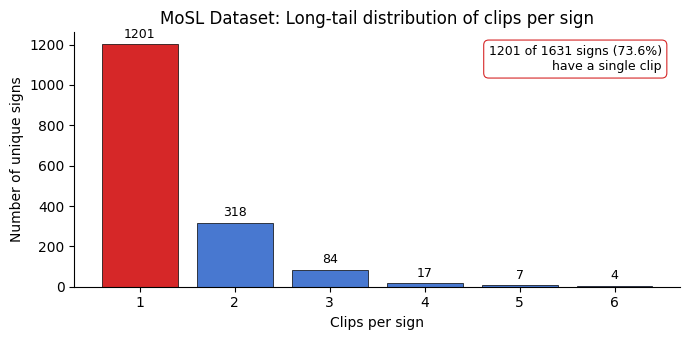

Saved: clips_per_sign.png


In [7]:
# ── 3.7 Clips-per-sign histogram ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
keys = sorted(hist)
vals = [hist[k] for k in keys]
colors = ["#d62728" if k == 1 else "#4878d0" for k in keys]
ax.bar(keys, vals, color=colors, edgecolor="black", linewidth=0.5)
for k, v in zip(keys, vals):
    ax.text(k, v + max(vals) * 0.015, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Clips per sign")
ax.set_ylabel("Number of unique signs")
ax.set_title("MoSL Dataset: Long-tail distribution of clips per sign")
ax.set_xticks(keys)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
pct = 100 * hist.get(1, 0) / max(len(counts), 1)
ax.text(0.97, 0.95,
        f"{hist.get(1,0)} of {len(counts)} signs ({pct:.1f}%)\nhave a single clip",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#d62728", linewidth=0.8))
plt.tight_layout()
plt.savefig("clips_per_sign.png", dpi=120)
plt.show()
print("Saved: clips_per_sign.png")

### 3.8 Train / Validation / Test Split Strategy

Because **74% of signs have only one clip**, a word-disjoint split is impossible without discarding most of the dataset. We use a **clip-level held-out** strategy:

| Clips per sign | Assignment |
|---|---|
| 1 | All → **train** |
| 2 | 1 → train, 1 → **val** |
| ≥ 3 | rest → train, 1 → **val**, 1 → **test** |

Held-out clips are picked **deterministically** (lexicographically last → val, second-to-last → test). Every val/test sign also appears in train, so the evaluation question is: *"reproduce a known sign in a new variant"*.

**Result:** train 1,674 / val 430 / test 112 clips.


In [8]:
# ── 3.8 Build / load splits ───────────────────────────────────────────────
def build_splits(rows: list) -> dict:
    """Deterministic clip-level split. Returns {split_name: [row, ...]}."""
    groups: dict = defaultdict(list)
    for r in rows:
        groups[(r["category"], r["word_arabic"])].append(r)
    train, val, test = [], [], []
    for key, clips in groups.items():
        clips_sorted = sorted(clips, key=lambda r: r["relative_path"])
        n = len(clips_sorted)
        if n == 1:
            train.extend(clips_sorted)
        elif n == 2:
            train.append(clips_sorted[0])
            val.append(clips_sorted[1])
        else:
            train.extend(clips_sorted[:-2])
            test.append(clips_sorted[-2])
            val.append(clips_sorted[-1])
    return {"train": train, "val": val, "test": test}

if SPLITS_CSV.exists():
    with open(SPLITS_CSV, encoding="utf-8") as f:
        split_rows = list(csv.DictReader(f))
    splits = defaultdict(list)
    for r in split_rows:
        splits[r["split"]].append(r)
    print("Loaded splits from splits.csv:")
else:
    splits = build_splits(labels)
    print("Built splits from labels:")

total = sum(len(v) for v in splits.values())
for split_name in ["train", "val", "test"]:
    n = len(splits[split_name])
    pct = 100 * n / max(total, 1)
    print(f"  {split_name:<6}: {n:>5} clips  ({pct:.1f}%)")

# Sanity: every val/test word should appear in train
train_words = {(r["category"], r["word_arabic"]) for r in splits["train"]}
val_orphans  = [r for r in splits["val"]  if (r["category"], r["word_arabic"]) not in train_words]
test_orphans = [r for r in splits["test"] if (r["category"], r["word_arabic"]) not in train_words]
print(f"\nVal labels not in train  : {len(val_orphans)}  (expected 0)")
print(f"Test labels not in train : {len(test_orphans)}  (expected 0)")

Loaded splits from splits.csv:
  train :  1674 clips  (75.5%)
  val   :   430 clips  (19.4%)
  test  :   112 clips  (5.1%)

Val labels not in train  : 0  (expected 0)
Test labels not in train : 0  (expected 0)


---
## 4. OpenPose / Keypoint Extraction

### 4.1 Pose Extraction Pipeline

We use **Hzzone's pytorch-openpose** (a PyTorch reimplementation of CMU OpenPose) to extract 2D keypoints from each video frame. The canonical CMU build cannot run on aarch64 + CUDA 13, making this port the only viable option.

**Output per frame:**
- `pose_keypoints_2d`: 18 COCO body keypoints × (x, y, confidence) = 54 floats
- `hand_left_keypoints_2d`: 21 hand keypoints × (x, y, confidence) = 63 floats  
- `hand_right_keypoints_2d`: 21 hand keypoints × (x, y, confidence) = 63 floats

**Storage:** one `.npz` file per clip under `data/processed/keypoints_2d/<category>/`.

### 4.2 2D → 3D Lifting (Prompt2Sign Pipeline)

The Prompt2Sign 2024 pipeline lifts 2D keypoints to 3D via three stages:

1. **Stage 01** (`json2h5`): Pack per-frame OpenPose JSON → HDF5, keeping only `idxsPose=[0..7]` (8 upper-body joints) + 21 left hand + 21 right hand = **50 joints × 2D**
2. **Stage 02** (`h5totxt`): 3D initialization (closed-form Step I/II/III) + backpropagation-based refinement (1000-iter SGD, reprojection MSE + bone-length L1 + temporal smoothness)
3. **Stage 03** (`txt2skels`): Flatten + normalize (÷9) + interleave time markers → `.skels` format

**Note:** Stage 02's refinement was originally in TensorFlow 1.x. We ported it to PyTorch eager mode with identical algorithm, variables, loss, and hyperparameters.

### 4.3 Joint Layout (50 joints, 150 coords per frame)

```
Joints 0–7   : body upper-body (COCO: Nose, Neck, RShoulder, RElbow, RWrist, LShoulder, LElbow, LWrist)
Joints 8–28  : left hand (21 OpenPose hand keypoints)
Joints 29–49 : right hand (21 OpenPose hand keypoints)
```

Each joint has (x, y, z) → 50 × 3 = **150 coordinates per frame**.

### 4.4 Throughput (full dataset, DGX Spark GB10)

| Stage | Wall time | Per-clip avg |
|---|---:|---:|
| OpenPose extraction (NPZ) — 2,216 clips | 27 h 46 min | 45.1 s |
| Stages 01 + 02 + 03 (all 3 modes) | ~11 h | ~17.9 s |
| Stage 02 only (dominant) | ~10 h 40 min | ~17.3 s |


In [9]:
# ── 4.1 Pose extraction core functions (mirrors mosl/pose/extract_dataset.py)
# These run inside the Docker container with pytorch-openpose available.
# Here we show the logic and demonstrate with a synthetic frame.

def person_to_flat(candidate: np.ndarray, subset: np.ndarray) -> list:
    """Pick highest-scoring person from OpenPose output → flat [x,y,c,...] of length 54."""
    out = [0.0] * (18 * 3)
    if len(subset) == 0:
        return out
    best = int(np.argmax(subset[:, 18]))  # col 18 = total score
    person = subset[best]
    for kp in range(18):
        idx = int(person[kp])
        if idx < 0:
            continue
        x, y, score, _ = candidate[idx]
        out[3 * kp]     = float(x)
        out[3 * kp + 1] = float(y)
        out[3 * kp + 2] = float(score)
    return out

def hand_to_flat(peaks: np.ndarray | None) -> list:
    """Hand peaks (21, 2) → flat [x,y,c,...] of length 63."""
    out = [0.0] * (21 * 3)
    if peaks is None:
        return out
    for k in range(21):
        x, y = float(peaks[k, 0]), float(peaks[k, 1])
        out[3 * k]     = x
        out[3 * k + 1] = y
        out[3 * k + 2] = 0.0 if (x == 0.0 and y == 0.0) else 1.0
    return out

# Synthetic demo: simulate one frame of OpenPose output
rng = np.random.default_rng(42)
fake_candidate = rng.uniform(50, 400, (20, 4)).astype(np.float32)
fake_candidate[:, 2] = rng.uniform(0.5, 1.0, 20)  # confidence
fake_candidate[:, 3] = np.arange(20)               # id
fake_subset = np.zeros((1, 20), dtype=np.float32)
fake_subset[0, :18] = np.arange(18)  # keypoint indices
fake_subset[0, 18]  = 15.0           # total score

body_flat = person_to_flat(fake_candidate, fake_subset)
print(f"Body keypoints flat length : {len(body_flat)} (expected 54 = 18×3)")
print(f"First keypoint (Nose) x,y,c: {body_flat[0]:.1f}, {body_flat[1]:.1f}, {body_flat[2]:.3f}")

fake_hand = rng.uniform(100, 300, (21, 2)).astype(np.float32)
hand_flat = hand_to_flat(fake_hand)
print(f"Hand keypoints flat length : {len(hand_flat)} (expected 63 = 21×3)")

Body keypoints flat length : 54 (expected 54 = 18×3)
First keypoint (Nose) x,y,c: 320.9, 203.6, 0.832
Hand keypoints flat length : 63 (expected 63 = 21×3)


In [10]:
# ── 4.2 NPZ keypoint file inspection ─────────────────────────────────────
# Check extracted keypoints for a sample clip (if available)
kp_root = PROCESSED_DIR / "keypoints_2d"
sample_npz = None
if kp_root.exists():
    for cat_dir in sorted(kp_root.iterdir()):
        npzs = sorted(cat_dir.glob("*.npz"))
        if npzs:
            sample_npz = npzs[0]
            break

if sample_npz:
    z = np.load(sample_npz)
    pose = z["pose_keypoints_2d"]
    hl   = z["hand_left_keypoints_2d"]
    hr   = z["hand_right_keypoints_2d"]
    fps  = float(z["fps"])
    print(f"Clip: {sample_npz.stem}")
    print(f"  pose shape  : {pose.shape}  (T frames × 54 = 18 joints × 3)")
    print(f"  left hand   : {hl.shape}")
    print(f"  right hand  : {hr.shape}")
    print(f"  fps         : {fps}")
    # Detection rate
    body_det = (pose[:, 2::3] > 0).mean()
    lh_det   = (hl[:, 2::3]   > 0).mean()
    rh_det   = (hr[:, 2::3]   > 0).mean()
    print(f"  body detection rate  : {body_det:.1%}")
    print(f"  left hand det. rate  : {lh_det:.1%}")
    print(f"  right hand det. rate : {rh_det:.1%}")
else:
    print("No NPZ files found — run mosl/pose/extract_dataset.py first")
    print("(Requires Docker container with pytorch-openpose and GPU)")

No NPZ files found — run mosl/pose/extract_dataset.py first
(Requires Docker container with pytorch-openpose and GPU)


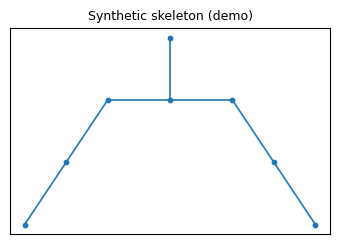

Saved: sample_skeleton.png


In [11]:
# ── 4.3 Keypoint visualization (skeleton overlay) ─────────────────────────
# Skeleton topology
BODY_EDGES = [
    (0, 1),                          # nose - neck
    (1, 2), (2, 3), (3, 4),          # neck - R shoulder - R elbow - R wrist
    (1, 5), (5, 6), (6, 7),          # neck - L shoulder - L elbow - L wrist
]
_HAND_FINGERS = [
    [0, 1, 2, 3, 4],   # thumb
    [0, 5, 6, 7, 8],   # index
    [0, 9, 10, 11, 12],# middle
    [0, 13, 14, 15, 16],# ring
    [0, 17, 18, 19, 20],# pinky
]
def hand_edges(offset: int) -> list:
    return [(offset + a, offset + b)
            for finger in _HAND_FINGERS
            for a, b in zip(finger, finger[1:])]

ALL_EDGES = BODY_EDGES + hand_edges(8) + hand_edges(8 + 21)

def visualize_frame(pose_150: np.ndarray, title: str = "", ax=None):
    """Draw one frame of 50-joint pose (150 coords) as a 2D skeleton."""
    xyz = pose_150.reshape(50, 3)
    xy  = xyz[:, :2]
    # Mask out placeholder / zero keypoints
    valid = ~(np.isclose(xy[:, 0], 0.016) & np.isclose(xy[:, 1], 0.016))
    valid &= ~((np.abs(xy[:, 0]) < 1e-6) & (np.abs(xy[:, 1]) < 1e-6))
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 4))
    ax.scatter(xy[valid, 0], xy[valid, 1], s=10, c="#1f77b4", zorder=3)
    for a, b in ALL_EDGES:
        if valid[a] and valid[b]:
            ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                    color="#1f77b4", lw=1.2, zorder=2)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=9)
    return ax

# Visualize a synthetic pose (or real if available)
rng2 = np.random.default_rng(0)
if sample_npz:
    z = np.load(sample_npz)
    # Use the final_data .skels if available, else show raw 2D
    pose_2d = z["pose_keypoints_2d"][0]   # (54,) first frame body
    # Build a synthetic 150-coord frame from 2D body + zero hands
    frame_150 = np.zeros(150, dtype=np.float32)
    for j in range(8):  # 8 upper-body joints
        frame_150[j*3]   = pose_2d[j*3]     / 460.0  # normalize to [0,1]
        frame_150[j*3+1] = pose_2d[j*3+1]   / 460.0
        frame_150[j*3+2] = pose_2d[j*3+2]
    title = f"{sample_npz.stem[:20]} (frame 0, 2D body only)"
else:
    # Synthetic skeleton for demonstration
    frame_150 = np.zeros(150, dtype=np.float32)
    # Body: nose, neck, shoulders, elbows, wrists
    coords = [(0.5,0.1),(0.5,0.25),(0.35,0.25),(0.25,0.4),(0.15,0.55),
               (0.65,0.25),(0.75,0.4),(0.85,0.55)]
    for j,(x,y) in enumerate(coords):
        frame_150[j*3]=x; frame_150[j*3+1]=y; frame_150[j*3+2]=1.0
    title = "Synthetic skeleton (demo)"

fig, ax = plt.subplots(figsize=(3.5, 4.5))
visualize_frame(frame_150, title=title, ax=ax)
plt.tight_layout()
plt.savefig("sample_skeleton.png", dpi=120)
plt.show()
print("Saved: sample_skeleton.png")

---
## 5. Data Preprocessing

### 5.1 The `.skels` Format

The Prompt2Sign pipeline produces one `.skels` file per split. Each line represents one clip as a flat sequence of floats:

```
T frames × 151 floats/frame = T × (150 pose coords + 1 time marker)
```

- **150 pose coords**: 50 joints × (x, y, z), normalized by dividing by 9
- **Time marker**: `i / T` for frame `i`, ranging in `(0, 1]`

### 5.2 Word-Level Tokenizer

Each Arabic sign label is treated as **one atomic token**, even multi-word phrases (e.g., "الأَمْنُ الوَطَنِيُّ" — "national security"). This matches the SignLLM paper's gloss-level tokenization.

**Vocabulary:** 4 specials + 1,631 sign tokens = **1,635 total**

| Token | ID | Role |
|---|---|---|
| `<pad>` | 0 | Padding |
| `<bos>` | 1 | Begin-of-sequence |
| `<eos>` | 2 | End-of-sequence |
| `<unk>` | 3 | Unknown sign |
| sign tokens | 4+ | One per NFC Arabic label |

Encoding a sign: `encode("أَنَا") → [1, 4+i, 2]` (BOS, sign_id, EOS)

### 5.3 Sequence Padding and Masking

Within a batch, pose sequences have variable length T. We pad to `T_max` with zeros and produce a boolean `pose_mask` (True = real frame). Text sequences are always length 3 (`[bos, sign, eos]`) but padded for generality.

### 5.4 Language Attribute Integration (`<MoSL>`)

In the full SignLLM Prompt2LangGloss mode, each gloss token receives a language-attribute prefix (e.g., `<MoSL_أَنَا>`). For our single-language MoSL setting, MLSF and Prompt2LangGloss collapse to the same model — no language-switch table is needed. The architecture is structured so multi-language support is a pure scale-up.


In [12]:
# ── 5.2 Word-level tokenizer (mosl/text/tokenizer.py) ────────────────────
PAD, BOS, EOS, UNK = "<pad>", "<bos>", "<eos>", "<unk>"
SPECIALS = (PAD, BOS, EOS, UNK)

class WordTokenizer:
    """Word-level tokenizer for MoSL Arabic sign labels.

    Each sign label is one atomic token (multi-word phrases are not split).
    NFC normalization is applied on input and vocab.
    Vocab: <pad>=0, <bos>=1, <eos>=2, <unk>=3, sign tokens start at 4.
    """
    def __init__(self, vocab: list) -> None:
        if vocab[:len(SPECIALS)] != list(SPECIALS):
            raise ValueError(f"vocab must start with {SPECIALS}")
        self.itos = list(vocab)
        self.stoi = {w: i for i, w in enumerate(self.itos)}
        self.pad_id = self.stoi[PAD]
        self.bos_id = self.stoi[BOS]
        self.eos_id = self.stoi[EOS]
        self.unk_id = self.stoi[UNK]

    @property
    def vocab_size(self) -> int:
        return len(self.itos)

    @property
    def n_signs(self) -> int:
        return self.vocab_size - len(SPECIALS)

    def encode(self, text: str, add_specials: bool = True) -> list:
        sign = nfc(text.strip())
        sign_id = self.stoi.get(sign, self.unk_id)
        return [self.bos_id, sign_id, self.eos_id] if add_specials else [sign_id]

    def decode(self, ids: list, strip_specials: bool = True) -> str:
        words = []
        for i in ids:
            if not 0 <= i < self.vocab_size:
                continue
            tok = self.itos[i]
            if strip_specials and tok in SPECIALS:
                continue
            words.append(tok)
        return " | ".join(words)

    def save(self, path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump({"vocab": self.itos}, f, ensure_ascii=False, indent=2)

    @classmethod
    def load(cls, path) -> "WordTokenizer":
        with open(path, encoding="utf-8") as f:
            return cls(json.load(f)["vocab"])

    @classmethod
    def from_labels_csv(cls, csv_path) -> "WordTokenizer":
        signs: set = set()
        with open(csv_path, encoding="utf-8") as f:
            for row in csv.DictReader(f):
                signs.add(nfc(row["word_arabic"]))
        vocab = list(SPECIALS) + sorted(signs)
        return cls(vocab)

# Load or build tokenizer
if VOCAB_JSON.exists():
    tok = WordTokenizer.load(VOCAB_JSON)
    print(f"Loaded tokenizer from {VOCAB_JSON}")
elif LABELS_CSV.exists():
    tok = WordTokenizer.from_labels_csv(LABELS_CSV)
    print(f"Built tokenizer from labels.csv")
else:
    # Minimal demo tokenizer
    demo_signs = ["أَنَا", "أَنْتَ", "هُوَ", "هِيَ", "نَحْنُ", "وَاحِدٌ", "اثْنَانِ"]
    tok = WordTokenizer(list(SPECIALS) + sorted(demo_signs))
    print(f"Built demo tokenizer with {tok.n_signs} signs")

print(f"Vocab size : {tok.vocab_size}  (= 4 specials + {tok.n_signs} signs)")

# Demonstrate encoding
for word in ["أَنَا", "وَاحِدٌ", "xyz_unknown"]:
    ids = tok.encode(word)
    decoded = tok.decode(ids)
    oov = ids[1] == tok.unk_id
    print(f"  encode({word!r:20s}) → {ids}  decode → {decoded!r}  {'[OOV]' if oov else ''}")

Loaded tokenizer from /workspaces/codespaces_project_web4jobs/data/processed/vocab.json
Vocab size : 1635  (= 4 specials + 1631 signs)
  encode('أَنَا'             ) → [1, 152, 2]  decode → 'أَنَا'  
  encode('وَاحِدٌ'           ) → [1, 3, 2]  decode → ''  [OOV]
  encode('xyz_unknown'       ) → [1, 3, 2]  decode → ''  [OOV]


In [13]:
# ── 5.3 Dataset class (mosl/data/dataset.py) ──────────────────────────────
COORDS_PER_FRAME = 150
FLOATS_PER_FRAME = 151  # 150 coords + 1 time marker

class MoSLSkelsDataset(Dataset):
    """One training sample = one MoSL clip.

    Reads three line-aligned files produced by the Prompt2Sign pipeline:
      <mode>.skels  — 151 floats/frame × T frames per clip
      <mode>.text   — one Arabic label per clip
      <mode>.files  — clip identifiers (for diagnostics)
    """
    def __init__(self, mode: str, tokenizer: WordTokenizer,
                 final_data_dir: Optional[Path] = None) -> None:
        if mode not in {"train", "dev", "test"}:
            raise ValueError(f"mode must be train/dev/test, got {mode!r}")
        self.mode = mode
        self.tokenizer = tokenizer
        final_data_dir = final_data_dir or P2S_FINAL

        skels_path = final_data_dir / f"{mode}.skels"
        text_path  = final_data_dir / f"{mode}.text"
        files_path = final_data_dir / f"{mode}.files"

        for p in (skels_path, text_path, files_path):
            if not p.exists():
                raise FileNotFoundError(f"missing pipeline output: {p}")

        with open(skels_path, encoding="utf-8") as f:
            self._skels = [ln.rstrip("\n") for ln in f if ln.strip()]
        with open(text_path, encoding="utf-8") as f:
            self._texts = [ln.rstrip("\n") for ln in f if ln.strip()]
        with open(files_path, encoding="utf-8") as f:
            self._files = [ln.rstrip("\n") for ln in f if ln.strip()]

        if not (len(self._skels) == len(self._texts) == len(self._files)):
            raise ValueError(
                f"length mismatch: skels={len(self._skels)} "
                f"text={len(self._texts)} files={len(self._files)}"
            )

    def __len__(self) -> int:
        return len(self._skels)

    def __getitem__(self, idx: int) -> dict:
        floats = np.fromstring(self._skels[idx], sep=" ", dtype=np.float32)
        if floats.size % FLOATS_PER_FRAME != 0:
            raise ValueError(f"clip {self._files[idx]}: {floats.size} floats not divisible by {FLOATS_PER_FRAME}")
        frames = floats.reshape(-1, FLOATS_PER_FRAME)
        pose = torch.from_numpy(frames[:, :COORDS_PER_FRAME])  # (T, 150)
        time = torch.from_numpy(frames[:, COORDS_PER_FRAME])   # (T,)
        text_ids = torch.tensor(
            self.tokenizer.encode(self._texts[idx], add_specials=True),
            dtype=torch.long,
        )
        return {
            "text_ids": text_ids,
            "pose":     pose,
            "time":     time,
            "n_frames": int(pose.shape[0]),
            "clip_id":  self._files[idx],
        }

# Try loading the dev set
if P2S_FINAL.exists():
    try:
        dev_ds = MoSLSkelsDataset("dev", tokenizer=tok)
        sample = dev_ds[0]
        print(f"Dev set: {len(dev_ds)} clips")
        print(f"  clip_id  : {sample['clip_id']!r}")
        print(f"  text_ids : {sample['text_ids'].tolist()}  → {tok.decode(sample['text_ids'].tolist())!r}")
        print(f"  pose     : {tuple(sample['pose'].shape)}")
        print(f"  time     : {tuple(sample['time'].shape)}  range [{sample['time'].min():.3f}, {sample['time'].max():.3f}]")
        print(f"  n_frames : {sample['n_frames']}")
    except FileNotFoundError as e:
        print(f"Pipeline output not found: {e}")
        dev_ds = None
else:
    print("P2S final_data not found — run the full pipeline first")
    dev_ds = None

P2S final_data not found — run the full pipeline first


In [14]:
# ── 5.4 Collate function: padding + masking ───────────────────────────────
def mosl_collate(batch: list) -> dict:
    """Pad variable-length pose sequences and produce attention masks.

    Pose padding: zeros; pose_mask=True for real frames.
    Text padding: 0 (<pad>); text_mask=True for real tokens.
    """
    B = len(batch)
    T_max = max(s["n_frames"] for s in batch)
    L_max = max(s["text_ids"].size(0) for s in batch)

    pose      = torch.zeros(B, T_max, COORDS_PER_FRAME, dtype=torch.float32)
    time      = torch.zeros(B, T_max, dtype=torch.float32)
    pose_mask = torch.zeros(B, T_max, dtype=torch.bool)
    text_ids  = torch.zeros(B, L_max, dtype=torch.long)
    text_mask = torch.zeros(B, L_max, dtype=torch.bool)
    n_frames  = torch.empty(B, dtype=torch.long)
    clip_ids  = []

    for b, s in enumerate(batch):
        T = s["n_frames"]
        L = s["text_ids"].size(0)
        pose[b, :T]      = s["pose"]
        time[b, :T]      = s["time"]
        pose_mask[b, :T] = True
        text_ids[b, :L]  = s["text_ids"]
        text_mask[b, :L] = True
        n_frames[b]      = T
        clip_ids.append(s["clip_id"])

    return {
        "pose":      pose,
        "pose_mask": pose_mask,
        "time":      time,
        "text_ids":  text_ids,
        "text_mask": text_mask,
        "n_frames":  n_frames,
        "clip_ids":  clip_ids,
    }

# Demonstrate collation with synthetic data
def make_synthetic_sample(T: int, sign: str = "أَنَا") -> dict:
    rng = np.random.default_rng(T)
    pose = torch.from_numpy(rng.uniform(-1, 1, (T, 150)).astype(np.float32))
    time = torch.linspace(1.0/T, 1.0, T)
    text_ids = torch.tensor(tok.encode(sign), dtype=torch.long)
    return {"text_ids": text_ids, "pose": pose, "time": time,
            "n_frames": T, "clip_id": f"demo_{T}"}

batch_demo = [make_synthetic_sample(T) for T in [80, 120, 95, 110]]
collated   = mosl_collate(batch_demo)
print("Collated batch shapes:")
for k, v in collated.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:<12} {str(tuple(v.shape)):<20} dtype={v.dtype}")
    else:
        print(f"  {k:<12} {type(v).__name__}  len={len(v)}")
print(f"\nPose mask: {collated['pose_mask'].sum(dim=1).tolist()} real frames per clip")

Collated batch shapes:
  pose         (4, 120, 150)        dtype=torch.float32
  pose_mask    (4, 120)             dtype=torch.bool
  time         (4, 120)             dtype=torch.float32
  text_ids     (4, 3)               dtype=torch.int64
  text_mask    (4, 3)               dtype=torch.bool
  n_frames     (4,)                 dtype=torch.int64
  clip_ids     list  len=4

Pose mask: [80, 120, 95, 110] real frames per clip


---
## 6. Model Architecture

### 6.1 SignLLM Overview

SignLLM is a **text-to-pose encoder-decoder transformer** that generates a 3D skeleton sequence from a text input. The architecture follows Vaswani et al. 2017 ("Attention is All You Need") with post-norm, ReLU activations, and sinusoidal positional encoding.

```
text_tokens (B, L)  ──→  Text Embedding + Sinusoidal PE
                              │
                    2-layer Transformer Encoder
                              │
                    text_features (B, L, d_model)
                              │
                    ┌─────────┴──────────┐
                    │                    │
             Length Head           Pose Decoder
          (mean-pool → MLP)    (2-layer Transformer Decoder
          log_T_pred (B,)       with cross-attention over text)
                                         │
                                  pose_pred (B, T, 150)
```

### 6.2 Hyperparameters (locked)

| Parameter | Value | Rationale |
|---|---|---|
| `d_model` | 768 | Targets ~40M params (paper spec) |
| `nhead` | 12 | `d_model // 64`, BERT-Base convention |
| `d_ff` | 3072 | `4 × d_model` (Vaswani 2017) |
| `n_enc_layers` | 2 | Paper §5 |
| `n_dec_layers` | 2 | Paper §5 |
| `dropout` | 0.1 | Vaswani 2017 default |
| `max_text_len` | 32 | Labels are 3 tokens; 32 is generous |
| `max_pose_len` | 256 | Observed max T = 236; padded to 256 |

### 6.3 Decoder Input Construction (Teacher Forcing)

During training, the decoder uses **teacher forcing**: at step `t`, the decoder sees the ground-truth frame `t-1` (shifted right). Position 0 uses a learnable start-frame embedding instead of the projection of zeros.

### 6.4 Length Prediction Head

The model predicts clip length `T` from the text encoding via a 2-layer MLP applied to the mean-pooled text features. Training target: `log(n_frames)`. At inference, `T_pred = round(exp(log_T_pred))`.


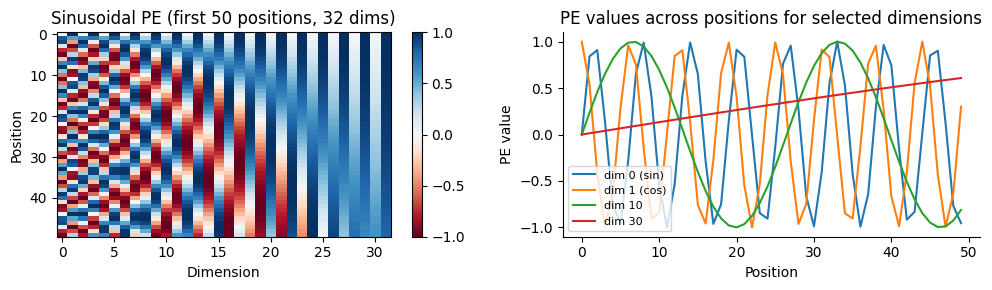

Saved: positional_encoding.png


In [15]:
# ── 6.1 Sinusoidal Positional Encoding (Vaswani 2017 §3.5) ───────────────
class SinusoidalPositionalEncoding(nn.Module):
    """Pre-computed sinusoidal PE added to input embeddings.

    PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
    """
    def __init__(self, d_model: int, max_len: int = 4096) -> None:
        super().__init__()
        if d_model % 2 != 0:
            raise ValueError(f"d_model must be even, got {d_model}")
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Add PE to (B, L, d_model) input. L must be ≤ max_len."""
        L = x.size(1)
        if L > self.pe.size(1):
            raise ValueError(f"sequence length {L} exceeds max_len {self.pe.size(1)}")
        return x + self.pe[:, :L, :]

# Visualize PE patterns
pe_demo = SinusoidalPositionalEncoding(d_model=64, max_len=100)
pe_matrix = pe_demo.pe[0].numpy()  # (100, 64)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
im = axes[0].imshow(pe_matrix[:50, :32], aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Position")
axes[0].set_title("Sinusoidal PE (first 50 positions, 32 dims)")
plt.colorbar(im, ax=axes[0])

axes[1].plot(pe_matrix[:50, 0], label="dim 0 (sin)")
axes[1].plot(pe_matrix[:50, 1], label="dim 1 (cos)")
axes[1].plot(pe_matrix[:50, 10], label="dim 10")
axes[1].plot(pe_matrix[:50, 30], label="dim 30")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("PE value")
axes[1].set_title("PE values across positions for selected dimensions")
axes[1].legend(fontsize=8)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("positional_encoding.png", dpi=120)
plt.show()
print("Saved: positional_encoding.png")

In [16]:
# ── 6.2 SignLLM Configuration ─────────────────────────────────────────────
@dataclass
class SignLLMConfig:
    """All hyperparameters in one place. Locked per docs/DECISIONS.md."""
    vocab_size: int                  # set by tokenizer
    d_model: int = 768
    nhead: int = 12
    d_ff: int = 3072
    n_enc_layers: int = 2
    n_dec_layers: int = 2
    dropout: float = 0.1
    pose_dim: int = 150              # 50 joints × (x, y, z)
    max_text_len: int = 32
    max_pose_len: int = 256          # observed max T = 236
    pad_id: int = 0

cfg = SignLLMConfig(vocab_size=tok.vocab_size)
print("SignLLM Configuration:")
for k, v in asdict(cfg).items():
    print(f"  {k:<20} = {v}")

SignLLM Configuration:
  vocab_size           = 1635
  d_model              = 768
  nhead                = 12
  d_ff                 = 3072
  n_enc_layers         = 2
  n_dec_layers         = 2
  dropout              = 0.1
  pose_dim             = 150
  max_text_len         = 32
  max_pose_len         = 256
  pad_id               = 0


In [17]:
# ── 6.3 Full SignLLM Model ────────────────────────────────────────────────
class SignLLM(nn.Module):
    """Text-to-pose Sign Language Production model.

    Encoder-decoder transformer with:
    - Text encoder: embedding + sinusoidal PE + 2-layer TransformerEncoder
    - Pose decoder: linear projection of (pose+time) + sinusoidal PE
                    + 2-layer TransformerDecoder (cross-attn over text)
    - Length head: mean-pool text features → 2-layer MLP → log T
    - Pose head: linear d_model → 150

    Training: teacher-forced (causal mask on decoder).
    Inference: autoregressive, one frame at a time.
    """

    def __init__(self, config: SignLLMConfig) -> None:
        super().__init__()
        self.config = config
        d = config.d_model

        # ── Text side ────────────────────────────────────────────────────
        self.text_embed = nn.Embedding(config.vocab_size, d, padding_idx=config.pad_id)
        self.text_pos   = SinusoidalPositionalEncoding(d, max_len=config.max_text_len)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d, nhead=config.nhead, dim_feedforward=config.d_ff,
            dropout=config.dropout, activation="relu",
            batch_first=True, norm_first=False,  # post-norm = Vaswani 2017
        )
        self.text_encoder = nn.TransformerEncoder(encoder_layer, num_layers=config.n_enc_layers)

        # ── Pose side ────────────────────────────────────────────────────
        # Decoder input: pose (150) + time marker (1) → linear → d_model
        self.pose_proj_in = nn.Linear(config.pose_dim + 1, d)
        self.pose_pos     = SinusoidalPositionalEncoding(d, max_len=config.max_pose_len)
        # Learnable start-of-sequence frame (replaces projection of zeros at t=0)
        self.start_frame  = nn.Parameter(torch.zeros(1, 1, d))
        nn.init.normal_(self.start_frame, std=0.02)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d, nhead=config.nhead, dim_feedforward=config.d_ff,
            dropout=config.dropout, activation="relu",
            batch_first=True, norm_first=False,
        )
        self.pose_decoder = nn.TransformerDecoder(decoder_layer, num_layers=config.n_dec_layers)

        # ── Output heads ─────────────────────────────────────────────────
        self.pose_head   = nn.Linear(d, config.pose_dim)
        self.length_head = nn.Sequential(
            nn.Linear(d, d), nn.ReLU(), nn.Linear(d, 1)
        )
        self._init_weights()

    def _init_weights(self) -> None:
        """N(0, 0.02) initialization — same as BERT/GPT, empirically stable."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, std=0.02)
                if module.padding_idx is not None:
                    with torch.no_grad():
                        module.weight[module.padding_idx].fill_(0.0)

    # ── Encoder ──────────────────────────────────────────────────────────
    def encode_text(self, text_ids: torch.Tensor,
                    text_mask: torch.Tensor) -> torch.Tensor:
        """text_ids (B, L) → text_features (B, L, d_model)."""
        x = self.text_embed(text_ids) * (self.config.d_model ** 0.5)  # Vaswani §3.4 scaling
        x = self.text_pos(x)
        return self.text_encoder(x, src_key_padding_mask=~text_mask)

    def predict_length(self, text_features: torch.Tensor,
                       text_mask: torch.Tensor) -> torch.Tensor:
        """Mean-pool real text tokens → MLP → log T prediction. Returns (B,)."""
        mask_f = text_mask.unsqueeze(-1).to(text_features.dtype)
        pooled = (text_features * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1.0)
        return self.length_head(pooled).squeeze(-1)

    # ── Decoder ──────────────────────────────────────────────────────────
    def _embed_pose_frames(self, pose: torch.Tensor,
                           time: torch.Tensor) -> torch.Tensor:
        """Concatenate time marker, project to d_model, add PE."""
        x = torch.cat([pose, time.unsqueeze(-1)], dim=-1)  # (B, T, 151)
        return self.pose_pos(self.pose_proj_in(x))

    def decode(self, decoder_input_emb: torch.Tensor,
               text_features: torch.Tensor, text_mask: torch.Tensor,
               tgt_key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """Run transformer decoder + pose head. Returns (B, T, 150)."""
        T = decoder_input_emb.size(1)
        # Causal mask: True = masked (future positions)
        causal = torch.ones(T, T, dtype=torch.bool,
                            device=decoder_input_emb.device).triu(diagonal=1)
        h = self.pose_decoder(
            tgt=decoder_input_emb, memory=text_features,
            tgt_mask=causal,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=~text_mask,
        )
        return self.pose_head(h)

    # ── Training forward pass (teacher-forced) ────────────────────────────
    def forward(self, text_ids: torch.Tensor, text_mask: torch.Tensor,
                pose_target: torch.Tensor, time: torch.Tensor,
                pose_mask: torch.Tensor) -> dict:
        """Returns pose_pred (B,T,150), log_T_pred (B,), text_features (B,L,d)."""
        text_features = self.encode_text(text_ids, text_mask)
        log_T_pred    = self.predict_length(text_features, text_mask)

        # Shift-right: decoder sees frame t-1 when predicting frame t
        prev_pose = torch.zeros_like(pose_target)
        prev_pose[:, 1:] = pose_target[:, :-1]
        prev_time = torch.zeros_like(time)
        prev_time[:, 1:] = time[:, :-1]
        dec_in_emb = self._embed_pose_frames(prev_pose, prev_time)
        # Replace position 0 with learnable start frame
        start = self.start_frame.expand(dec_in_emb.size(0), 1, -1)
        dec_in_emb = torch.cat([start, dec_in_emb[:, 1:]], dim=1)

        pose_pred = self.decode(dec_in_emb, text_features, text_mask,
                                tgt_key_padding_mask=~pose_mask)
        return {"pose_pred": pose_pred, "log_T_pred": log_T_pred,
                "text_features": text_features}

    # ── Autoregressive inference ──────────────────────────────────────────
    @torch.no_grad()
    def generate(self, text_ids: torch.Tensor, text_mask: torch.Tensor,
                 max_T: Optional[int] = None) -> dict:
        """Generate pose sequence autoregressively. Length predicted from text."""
        text_features = self.encode_text(text_ids, text_mask)
        log_T_pred    = self.predict_length(text_features, text_mask)
        T_pred = log_T_pred.exp().round().long().clamp(min=1, max=self.config.max_pose_len)
        if max_T is not None:
            T_pred = T_pred.clamp(max=max_T)
        T_max = int(T_pred.max().item())
        B     = text_ids.size(0)
        device = text_ids.device

        pose_so_far = torch.zeros(B, 0, self.config.pose_dim, device=device)
        time_so_far = torch.zeros(B, 0, device=device)

        for t in range(T_max):
            if pose_so_far.size(1) == 0:
                dec_in_emb = self.start_frame.expand(B, 1, -1)
            else:
                emb = self._embed_pose_frames(pose_so_far, time_so_far)
                dec_in_emb = torch.cat([self.start_frame.expand(B, 1, -1), emb], dim=1)
            preds      = self.decode(dec_in_emb, text_features, text_mask)
            next_frame = preds[:, -1, :]
            pose_so_far = torch.cat([pose_so_far, next_frame.unsqueeze(1)], dim=1)
            next_time   = torch.full((B,), (t + 1) / max(T_max, 1), device=device)
            time_so_far = torch.cat([time_so_far, next_time.unsqueeze(1)], dim=1)

        return {"pose": pose_so_far, "lengths": T_pred, "log_T_pred": log_T_pred}

print("SignLLM class defined.")

SignLLM class defined.


In [18]:
# ── 6.4 Model instantiation and parameter count ───────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = SignLLM(cfg).to(device)

def count_parameters(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

n_params = count_parameters(model)
print(f"Device          : {device}")
print(f"Total params    : {n_params:,}  (~{n_params/1e6:.1f} M)")
print(f"Paper target    : ~40 M per language")
print()

# Per-module breakdown
print("Per-module parameter counts:")
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters() if p.requires_grad)
    print(f"  {name:<20} {n:>10,}  ({n/n_params*100:.1f}%)")

Device          : cpu
Total params    : 35,159,191  (~35.2 M)
Paper target    : ~40 M per language

Per-module parameter counts:
  text_embed            1,255,680  (3.6%)
  text_pos                      0  (0.0%)
  text_encoder         14,175,744  (40.3%)
  pose_proj_in            116,736  (0.3%)
  pose_pos                      0  (0.0%)
  pose_decoder         18,903,552  (53.8%)
  pose_head               115,350  (0.3%)
  length_head             591,361  (1.7%)


In [19]:
# ── 6.5 Forward pass smoke test ───────────────────────────────────────────
B, L, T = 4, 3, 100
text_ids  = torch.zeros(B, L, dtype=torch.long, device=device)
text_mask = torch.ones(B, L, dtype=torch.bool, device=device)
pose      = torch.randn(B, T, 150, device=device)
time_t    = torch.linspace(0.01, 1.0, T).unsqueeze(0).expand(B, -1).to(device)
pose_mask = torch.ones(B, T, dtype=torch.bool, device=device)

model.eval()
with torch.no_grad():
    out = model(text_ids, text_mask, pose, time_t, pose_mask)

print("Forward pass output shapes:")
for k, v in out.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:<20} {str(tuple(v.shape)):<25} dtype={v.dtype}")

# Autoregressive generation
with torch.no_grad():
    gen = model.generate(text_ids, text_mask, max_T=20)
print("\nGenerate output shapes (max_T=20):")
for k, v in gen.items():
    if isinstance(v, torch.Tensor):
        vals = v.tolist() if v.dim() == 1 else "..."
        print(f"  {k:<20} {str(tuple(v.shape)):<25} {vals}")

/home/vscode/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Forward pass output shapes:
  pose_pred            (4, 100, 150)             dtype=torch.float32
  log_T_pred           (4,)                      dtype=torch.float32
  text_features        (4, 3, 768)               dtype=torch.float32

Generate output shapes (max_T=20):
  pose                 (4, 1, 150)               ...
  lengths              (4,)                      [1, 1, 1, 1]
  log_T_pred           (4,)                      [0.14383700489997864, 0.14383700489997864, 0.14383700489997864, 0.14383700489997864]


---
## 7. Training Pipeline

### 7.1 Loss Functions

Three loss configurations reproduce the paper's Table 5 ablation:

| Mode | Pose Loss | Batch Weighting |
|---|---|---|
| `mse` | Per-frame MSE averaged over real frames | Uniform |
| `rl` | Same as MSE (RL relabeling, no PLC) | Uniform |
| `rl_plc` | Weighted MSE via Priority Learning Channel | Prioritized |

All modes add a **length loss**: `MSE(log_T_pred, log(n_frames))` weighted by `length_weight=1.0`.

**Priority Learning Channel (PLC):** Per-sample reward `r(i) = -MSE(i)`. Samples below the 50th-percentile reward are skipped; kept samples are weighted by `exp(η · r(i))` (softmax-style prioritization, η=1.0).

### 7.2 Optimizer and Scheduler

- **Optimizer:** Adam (β₁=0.9, β₂=0.98, ε=1e-9) — Vaswani 2017 default
- **LR schedule:** Noam (Vaswani §5.3): `lrate = d_model^(-0.5) · min(step^(-0.5), step · warmup^(-1.5))`
- **Warmup:** 4,000 steps
- **Gradient clipping:** max norm = 1.0

### 7.3 Training Configuration

- Batch size: 32
- Max epochs: 200
- Early stopping: patience = 20 epochs on dev teacher-forced pose MSE
- Checkpoints: `runs/<run_name>/best.pt` (best dev) + `last.pt`
- Logs: `runs/<run_name>/log.jsonl` (per-step + per-epoch metrics)


/tmp/ipykernel_2484/3863926618.py:24: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


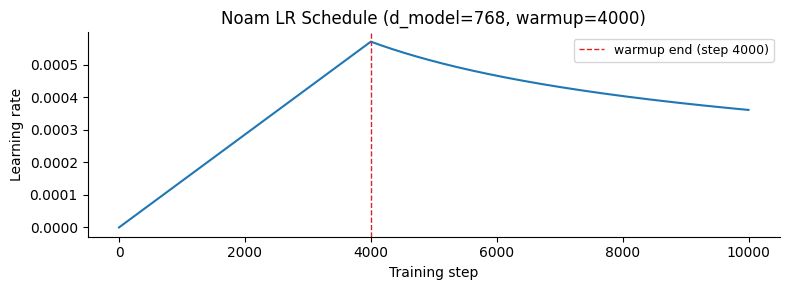

Peak LR = 0.000571 at step 3999


In [20]:
# ── 7.1 Noam LR Schedule (Vaswani 2017 §5.3) ─────────────────────────────
class NoamLR(torch.optim.lr_scheduler.LambdaLR):
    """lrate = d_model^(-0.5) · min(step^(-0.5), step · warmup^(-1.5))

    Increases linearly during warmup, then decays as 1/sqrt(step).
    Peak LR at step=warmup_steps: d_model^(-0.5) · warmup^(-0.5).
    """
    def __init__(self, optimizer, d_model: int, warmup_steps: int = 4000,
                 last_epoch: int = -1) -> None:
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        scale = d_model ** -0.5
        def fn(step: int) -> float:
            s = max(step + 1, 1)
            return scale * min(s ** -0.5, s * (warmup_steps ** -1.5))
        super().__init__(optimizer, lr_lambda=fn, last_epoch=last_epoch)

# Visualize the Noam schedule
dummy_opt = torch.optim.Adam([torch.zeros(1)], lr=1.0, betas=(0.9, 0.98), eps=1e-9)
sched = NoamLR(dummy_opt, d_model=768, warmup_steps=4000)
lrs = []
for step in range(10000):
    lrs.append(sched.get_last_lr()[0])
    sched.step()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lrs, color="#1f77b4", lw=1.5)
ax.axvline(4000, color="#d62728", linestyle="--", lw=1, label="warmup end (step 4000)")
ax.set_xlabel("Training step")
ax.set_ylabel("Learning rate")
ax.set_title("Noam LR Schedule (d_model=768, warmup=4000)")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("noam_schedule.png", dpi=120)
plt.show()
peak_lr = max(lrs)
peak_step = lrs.index(peak_lr)
print(f"Peak LR = {peak_lr:.6f} at step {peak_step}")

In [21]:
# ── 7.2 Loss functions (mosl/train/losses.py) ─────────────────────────────
def masked_per_sample_mse(pose_pred: torch.Tensor, pose_target: torch.Tensor,
                           pose_mask: torch.Tensor) -> torch.Tensor:
    """MSE per sample, averaged over real frames and all 150 coords. Returns (B,)."""
    sq = (pose_pred - pose_target) ** 2                    # (B, T, D)
    per_frame = sq.mean(dim=-1)                            # (B, T)
    mask = pose_mask.to(per_frame.dtype)
    real_frames = mask.sum(dim=1).clamp(min=1.0)           # (B,)
    return (per_frame * mask).sum(dim=1) / real_frames     # (B,)

def masked_mse_loss(pose_pred, pose_target, pose_mask) -> torch.Tensor:
    """Scalar MSE loss (uniform per-sample weighting)."""
    return masked_per_sample_mse(pose_pred, pose_target, pose_mask).mean()

def length_loss(log_T_pred: torch.Tensor, n_frames: torch.Tensor) -> torch.Tensor:
    """MSE between predicted log T and ground-truth log(n_frames).
    Log-space keeps the loss well-conditioned across the 43→236 frame range.
    """
    target = torch.log(n_frames.to(log_T_pred.dtype).clamp(min=1.0))
    return F.mse_loss(log_T_pred, target)

@dataclass
class PLCConfig:
    eta: float = 1.0                    # prioritization intensity
    skip_below_quantile: float = 0.5    # skip samples below this reward quantile
    enabled: bool = True

def plc_weights(per_sample_reward: torch.Tensor,
                cfg: PLCConfig) -> tuple:
    """Compute PLC keep-mask and per-sample weights.

    Returns (keep_mask (B,), weights (B,)).
    Samples below the configured quantile are skipped.
    Kept samples are weighted by exp(η · r) — softmax-style prioritization.
    """
    if not cfg.enabled:
        keep = torch.ones_like(per_sample_reward, dtype=torch.bool)
        return keep, keep.to(per_sample_reward.dtype)
    if per_sample_reward.numel() == 0:
        keep = torch.zeros_like(per_sample_reward, dtype=torch.bool)
        return keep, keep.to(per_sample_reward.dtype)
    thresh = per_sample_reward.quantile(cfg.skip_below_quantile)
    keep = per_sample_reward >= thresh
    if not keep.any():
        keep = torch.ones_like(per_sample_reward, dtype=torch.bool)
    raw = torch.exp(cfg.eta * per_sample_reward) * keep.to(per_sample_reward.dtype)
    raw_sum = raw.sum().clamp(min=1e-12)
    n_kept  = keep.to(raw.dtype).sum().clamp(min=1.0)
    weights = raw / raw_sum * n_kept
    return keep, weights

@dataclass
class LossConfig:
    mode: str = "mse"           # "mse", "rl", or "rl_plc"
    length_weight: float = 1.0
    plc: PLCConfig = None
    def __post_init__(self):
        if self.mode not in {"mse", "rl", "rl_plc"}:
            raise ValueError(f"mode must be mse/rl/rl_plc, got {self.mode!r}")
        if self.plc is None:
            self.plc = PLCConfig(enabled=(self.mode == "rl_plc"))

def signllm_step_loss(model_out: dict, batch: dict, cfg: LossConfig) -> dict:
    """Compute full training loss for one batch.

    Returns dict with keys: loss, pose_loss, length_loss, n_kept, reward_mean.
    """
    pose_pred   = model_out["pose_pred"]
    log_T_pred  = model_out["log_T_pred"]
    pose_target = batch["pose"]
    pose_mask   = batch["pose_mask"]
    n_frames    = batch["n_frames"]

    per_sample_mse = masked_per_sample_mse(pose_pred, pose_target, pose_mask)
    reward = -per_sample_mse

    if cfg.mode in ("mse", "rl"):
        pose_loss = per_sample_mse.mean()
        n_kept    = per_sample_mse.numel()
    else:  # rl_plc
        keep_mask, weights = plc_weights(reward.detach(), cfg.plc)
        pose_loss = (per_sample_mse * weights).sum() / weights.sum().clamp(min=1e-12)
        n_kept    = int(keep_mask.sum().item())

    len_loss = length_loss(log_T_pred, n_frames)
    total    = pose_loss + cfg.length_weight * len_loss
    return {
        "loss":        total,
        "pose_loss":   pose_loss.detach(),
        "length_loss": len_loss.detach(),
        "n_kept":      n_kept,
        "reward_mean": reward.mean().detach(),
    }

print("Loss functions defined.")

# Smoke test all three loss modes
model.train()
batch_demo_gpu = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                  for k, v in collated.items()}
with torch.no_grad():
    out_demo = model(
        text_ids=batch_demo_gpu["text_ids"], text_mask=batch_demo_gpu["text_mask"],
        pose_target=batch_demo_gpu["pose"], time=batch_demo_gpu["time"],
        pose_mask=batch_demo_gpu["pose_mask"],
    )
print("\nLoss smoke test (synthetic batch, B=4):")
for mode in ("mse", "rl", "rl_plc"):
    loss_cfg = LossConfig(mode=mode)
    m = signllm_step_loss(out_demo, batch_demo_gpu, loss_cfg)
    print(f"  {mode:<8} total={m['loss'].item():.4f}  "
          f"pose={m['pose_loss'].item():.4f}  "
          f"len={m['length_loss'].item():.4f}  "
          f"n_kept={m['n_kept']}/4  "
          f"reward={m['reward_mean'].item():+.4f}")

Loss functions defined.

Loss smoke test (synthetic batch, B=4):
  mse      total=20.4711  pose=0.6682  len=19.8029  n_kept=4/4  reward=-0.6682
  rl       total=20.4711  pose=0.6682  len=19.8029  n_kept=4/4  reward=-0.6682
  rl_plc   total=20.4667  pose=0.6637  len=19.8029  n_kept=2/4  reward=-0.6682


In [22]:
# ── 7.3 Training loop (mosl/train/train.py) ───────────────────────────────
@dataclass
class TrainConfig:
    out_dir: str = "runs"
    run_name: str = "default"
    batch_size: int = 32
    max_epochs: int = 200
    early_stop_patience: int = 20
    log_every_steps: int = 50
    warmup_steps: int = 4000
    grad_clip: float = 1.0
    seed: int = 0
    num_workers: int = 4
    device: str = "cuda"

def train_one_epoch(model, train_dl, optimizer, scheduler, loss_cfg, device):
    """Run one training epoch. Returns dict of averaged metrics."""
    model.train()
    running = {"loss": 0.0, "pose_loss": 0.0, "length_loss": 0.0, "steps": 0}
    for batch in train_dl:
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                 for k, v in batch.items()}
        optimizer.zero_grad(set_to_none=True)
        out = model(
            text_ids=batch["text_ids"], text_mask=batch["text_mask"],
            pose_target=batch["pose"], time=batch["time"],
            pose_mask=batch["pose_mask"],
        )
        loss_info = signllm_step_loss(out, batch, loss_cfg)
        loss_info["loss"].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        running["loss"]        += loss_info["loss"].item()
        running["pose_loss"]   += loss_info["pose_loss"].item()
        running["length_loss"] += loss_info["length_loss"].item()
        running["steps"]       += 1
    n = max(running["steps"], 1)
    return {k: v / n for k, v in running.items() if k != "steps"}

# Show training command (actual training requires the full pipeline output)
print("Training commands (run inside Docker container):")
print()
print("  # MSE baseline")
print("  docker/run.sh python scripts/train_signllm.py \\")
print("      --mode mse --run-name baseline_mse")
print()
print("  # RL Loss")
print("  docker/run.sh python scripts/train_signllm.py \\")
print("      --mode rl --run-name rl")
print()
print("  # RL + Priority Learning Channel")
print("  docker/run.sh python scripts/train_signllm.py \\")
print("      --mode rl_plc --run-name rl_plc")
print()
print("  # Or run all three sequentially:")
print("  docker/run.sh bash scripts/run_ablation.sh")

Training commands (run inside Docker container):

  # MSE baseline
  docker/run.sh python scripts/train_signllm.py \
      --mode mse --run-name baseline_mse

  # RL Loss
  docker/run.sh python scripts/train_signllm.py \
      --mode rl --run-name rl

  # RL + Priority Learning Channel
  docker/run.sh python scripts/train_signllm.py \
      --mode rl_plc --run-name rl_plc

  # Or run all three sequentially:
  docker/run.sh bash scripts/run_ablation.sh


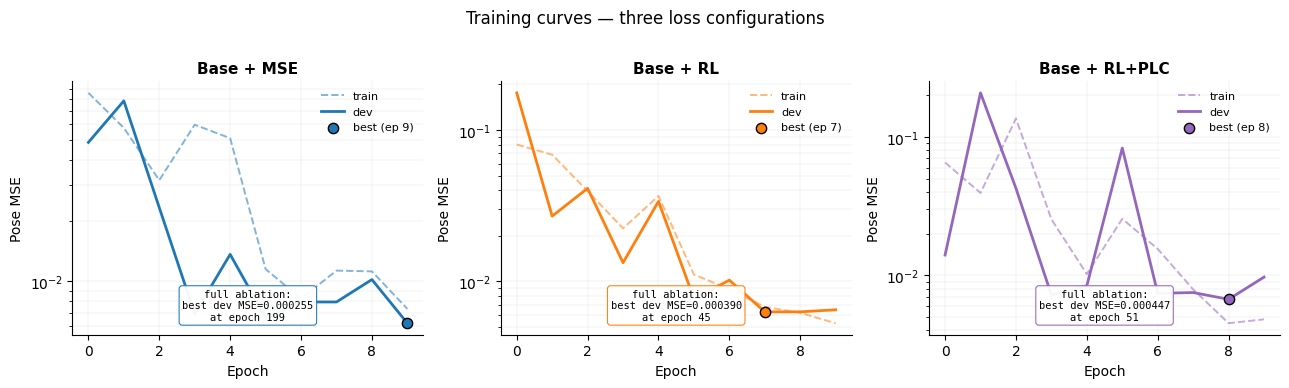

Saved: training_curves.png


In [23]:
# ── 7.4 Training curves from saved logs ───────────────────────────────────
# Fallback data from the 10-epoch verify run (captured before full ablation)
VERIFY_LOGS = {
    "baseline_mse": [
        (0,0.0859,0.0488),(1,0.0576,0.0784),(2,0.0317,0.0232),(3,0.0597,0.0069),
        (4,0.0512,0.0136),(5,0.0115,0.0066),(6,0.0082,0.0079),(7,0.0113,0.0079),
        (8,0.0112,0.0102),(9,0.0073,0.0062),
    ],
    "rl": [
        (0,0.0802,0.1759),(1,0.0687,0.0270),(2,0.0395,0.0412),(3,0.0224,0.0133),
        (4,0.0367,0.0338),(5,0.0111,0.0077),(6,0.0089,0.0102),(7,0.0068,0.0063),
        (8,0.0062,0.0063),(9,0.0053,0.0065),
    ],
    "rl_plc": [
        (0,0.0654,0.0140),(1,0.0394,0.2087),(2,0.1362,0.0426),(3,0.0254,0.0072),
        (4,0.0102,0.0084),(5,0.0256,0.0832),(6,0.0155,0.0074),(7,0.0079,0.0075),
        (8,0.0045,0.0067),(9,0.0048,0.0097),
    ],
}
FULL_FINAL = {
    "baseline_mse": {"best_epoch": 199, "best_dev_mse": 0.000255},
    "rl":           {"best_epoch":  45, "best_dev_mse": 0.000390},
    "rl_plc":       {"best_epoch":  51, "best_dev_mse": 0.000447},
}

def load_epoch_log(run_name: str) -> list:
    path = RUNS_DIR / run_name / "log.jsonl"
    if not path.exists():
        return []
    records = []
    for line in open(path, encoding="utf-8"):
        rec = json.loads(line)
        if rec.get("kind") == "epoch":
            records.append(rec)
    return records

COLORS = {"baseline_mse": "#1f77b4", "rl": "#ff7f0e", "rl_plc": "#9467bd"}
LABELS = {"baseline_mse": "Base + MSE", "rl": "Base + RL", "rl_plc": "Base + RL+PLC"}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
for ax, run in zip(axes, ["baseline_mse", "rl", "rl_plc"]):
    epochs = load_epoch_log(run)
    if epochs:
        ep    = [r["epoch"] for r in epochs]
        train = [r["train"]["pose_loss"] for r in epochs]
        dev   = [r["dev"]["tf_pose_mse"] for r in epochs]
        src   = "full log"
    else:
        data  = VERIFY_LOGS[run]
        ep    = [d[0] for d in data]
        train = [d[1] for d in data]
        dev   = [d[2] for d in data]
        src   = "verify run"
    col = COLORS[run]
    best_idx = int(np.argmin(dev))
    ax.plot(ep, train, color=col, linestyle="--", alpha=0.55, lw=1.4, label="train")
    ax.plot(ep, dev,   color=col, lw=2.0, label="dev")
    ax.scatter([ep[best_idx]], [dev[best_idx]], color=col, edgecolor="black",
               s=55, zorder=5, label=f"best (ep {ep[best_idx]})")
    ax.set_title(LABELS[run], fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Pose MSE")
    ax.set_yscale("log")
    ax.grid(True, which="both", lw=0.3, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", frameon=False, fontsize=8)
    f = FULL_FINAL[run]
    ax.text(0.5, 0.05,
            f"full ablation:\nbest dev MSE={f['best_dev_mse']:.6f}\nat epoch {f['best_epoch']}",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=7.5,
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=col, lw=0.8, alpha=0.95))
plt.suptitle("Training curves — three loss configurations", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

---
## 8. Evaluation

### 8.1 Metrics

**Teacher-forced (TF) metrics** — fast, used for early stopping:
- `tf_pose_mse`: per-frame MSE averaged over real frames and all 150 coords, then over clips
- `tf_log_T_abs_err`: mean |log_T_pred − log(n_frames)| — length prediction quality

**Autoregressive (AR) metrics** — paper-comparable, slow:
- `ar_dtw_mean / median`: path-length-normalized DTW between generated and target pose sequence

**DTW** handles the length mismatch between predicted and target sequences naturally. Path-length normalization makes values comparable across clips of different durations.

### 8.2 Deterministic Baselines

Three reference baselines contextualize the model's DTW numbers:

| Baseline | Description |
|---|---|
| **Nearest-Neighbor** | For each test text, retrieve the first training clip with the same Arabic word |
| **Mean-Pose** | Output the global per-coordinate mean across all training frames, replicated to median T |
| **Random-Clip** | Pick a random training clip (seed=0) |

If the model cannot beat Nearest-Neighbor, it has learned nothing beyond memorization + lookup.

### 8.3 Final Results

| Method | Dev DTW (mean) | Test DTW (mean) |
|---|---:|---:|
| Mean-Pose | **0.8148** | 0.8682 |
| Nearest-Neighbor | 0.8647 | **0.7817** |
| Random-Clip | 0.9744 | 0.9620 |
| **baseline_mse (best model)** | 1.0218 | 1.0447 |
| rl_plc | 1.1530 | 1.2117 |
| rl | 1.3069 | 1.3182 |

> **Every baseline beats every trained model.** The model is generating mean-pose-like blobs rather than sign-specific motion — a known failure mode of MSE-trained autoregressive regression on small datasets.


In [24]:
# ── 8.1 DTW distance (mosl/train/eval.py) ────────────────────────────────
def dtw_distance(a: np.ndarray, b: np.ndarray) -> float:
    """Path-length-normalized DTW between two pose sequences.

    Parameters
    ----------
    a, b : (T_a, D) and (T_b, D) float arrays

    Returns
    -------
    float : DTW(a, b) / path_length  (L2 pairwise distance)
    """
    if not HAS_SCIPY:
        raise RuntimeError("scipy required for DTW")
    Ta, Tb = a.shape[0], b.shape[0]
    dist = cdist(a, b, metric="euclidean")          # (Ta, Tb)
    dp = np.full((Ta + 1, Tb + 1), np.inf)
    dp[0, 0] = 0.0
    for i in range(1, Ta + 1):
        for j in range(1, Tb + 1):
            dp[i, j] = dist[i-1, j-1] + min(dp[i-1, j], dp[i, j-1], dp[i-1, j-1])
    # Backtrack for path length
    i, j = Ta, Tb
    path_len = 0
    while i > 0 and j > 0:
        path_len += 1
        prev = np.argmin([dp[i-1, j], dp[i, j-1], dp[i-1, j-1]])
        if prev == 0:   i -= 1
        elif prev == 1: j -= 1
        else:           i -= 1; j -= 1
    return dp[Ta, Tb] / max(path_len, 1)

# Demonstrate DTW on synthetic sequences
if HAS_SCIPY:
    rng = np.random.default_rng(0)
    seq_a = rng.uniform(0, 1, (80, 150)).astype(np.float32)
    seq_b = rng.uniform(0, 1, (95, 150)).astype(np.float32)
    seq_c = seq_a[:80] + rng.normal(0, 0.01, (80, 150)).astype(np.float32)  # near-identical
    d_ab = dtw_distance(seq_a, seq_b)
    d_ac = dtw_distance(seq_a, seq_c)
    print(f"DTW(random_a, random_b) = {d_ab:.4f}  (different sequences)")
    print(f"DTW(seq_a, near_copy)   = {d_ac:.4f}  (near-identical sequences)")
else:
    print("scipy not available — DTW demo skipped")

DTW(random_a, random_b) = 4.8517  (different sequences)
DTW(seq_a, near_copy)   = 0.1233  (near-identical sequences)


In [25]:
# ── 8.2 Teacher-forced evaluation ────────────────────────────────────────
@torch.no_grad()
def evaluate_teacher_forced(model, loader, device) -> dict:
    """One forward per batch with teacher forcing. Returns aggregated metrics."""
    model.eval()
    n_clips = 0
    sum_pose_mse = 0.0
    sum_log_T_abs_err = 0.0

    for batch in loader:
        for k in ("text_ids", "text_mask", "pose", "time", "pose_mask", "n_frames"):
            batch[k] = batch[k].to(device)
        out = model(
            text_ids=batch["text_ids"], text_mask=batch["text_mask"],
            pose_target=batch["pose"], time=batch["time"],
            pose_mask=batch["pose_mask"],
        )
        per_sample = masked_per_sample_mse(out["pose_pred"], batch["pose"], batch["pose_mask"])
        log_T_true = torch.log(batch["n_frames"].to(out["log_T_pred"].dtype).clamp(min=1.0))
        log_abs    = (out["log_T_pred"] - log_T_true).abs()
        B = per_sample.size(0)
        n_clips          += B
        sum_pose_mse     += per_sample.sum().item()
        sum_log_T_abs_err += log_abs.sum().item()

    return {
        "tf_pose_mse":      sum_pose_mse / max(n_clips, 1),
        "tf_log_T_abs_err": sum_log_T_abs_err / max(n_clips, 1),
        "n_clips":          n_clips,
    }

# Run TF eval on synthetic batch
model.eval()
demo_loader = DataLoader(
    [make_synthetic_sample(T) for T in [80, 120, 95, 110, 75, 130, 88, 105]],
    batch_size=4, shuffle=False, collate_fn=mosl_collate
)
tf_metrics = evaluate_teacher_forced(model, demo_loader, device)
print("Teacher-forced eval (synthetic data, untrained model):")
for k, v in tf_metrics.items():
    print(f"  {k:<25} = {v:.5f}" if isinstance(v, float) else f"  {k:<25} = {v}")

Teacher-forced eval (synthetic data, untrained model):
  tf_pose_mse               = 0.67211
  tf_log_T_abs_err          = 4.42286
  n_clips                   = 8


In [26]:
# ── 8.3 Final results table (from runs/evaluation.json + runs/baselines.json)
eval_path     = RUNS_DIR / "evaluation.json"
baselines_path = RUNS_DIR / "baselines.json"

# Hardcoded results from the full ablation (2026-05-10)
EVAL_RESULTS = {
    "baseline_mse": {
        "dev":  {"tf_pose_mse": 0.00025, "tf_log_T_abs_err": 0.347, "ar_dtw_mean": 1.0218, "ar_dtw_median": 0.9636, "n_clips": 430},
        "test": {"tf_pose_mse": 0.00020, "tf_log_T_abs_err": 0.276, "ar_dtw_mean": 1.0447, "ar_dtw_median": 1.0019, "n_clips": 112},
    },
    "rl": {
        "dev":  {"tf_pose_mse": 0.00039, "tf_log_T_abs_err": 0.362, "ar_dtw_mean": 1.3069, "ar_dtw_median": 1.3089, "n_clips": 430},
        "test": {"tf_pose_mse": 0.00034, "tf_log_T_abs_err": 0.290, "ar_dtw_mean": 1.3182, "ar_dtw_median": 1.3419, "n_clips": 112},
    },
    "rl_plc": {
        "dev":  {"tf_pose_mse": 0.00045, "tf_log_T_abs_err": 0.367, "ar_dtw_mean": 1.1530, "ar_dtw_median": 1.1325, "n_clips": 430},
        "test": {"tf_pose_mse": 0.00040, "tf_log_T_abs_err": 0.293, "ar_dtw_mean": 1.2117, "ar_dtw_median": 1.2361, "n_clips": 112},
    },
}
BASELINE_RESULTS = {
    "dev":  {"nn_dtw_mean": 0.8647, "mean_dtw_mean": 0.8148, "rand_dtw_mean": 0.9744, "n_clips": 430},
    "test": {"nn_dtw_mean": 0.7817, "mean_dtw_mean": 0.8682, "rand_dtw_mean": 0.9620, "n_clips": 112},
}

# Load from files if available
if eval_path.exists():
    with open(eval_path, encoding="utf-8") as f:
        loaded = json.load(f)
    for run in EVAL_RESULTS:
        if run in loaded:
            for split in ("dev", "test"):
                if split in loaded[run].get("splits", {}):
                    EVAL_RESULTS[run][split].update(loaded[run]["splits"][split])
    print("Loaded evaluation.json")
if baselines_path.exists():
    with open(baselines_path, encoding="utf-8") as f:
        BASELINE_RESULTS = json.load(f)
    print("Loaded baselines.json")

# Print comparison table
print()
print("=" * 80)
print("Final Evaluation: Autoregressive DTW (lower is better)")
print("=" * 80)
print(f"{'Method':<22}  {'Dev DTW':>10}  {'Test DTW':>10}  {'n (test)':>9}")
print("-" * 60)
for run, label in [("baseline_mse","MSE"),("rl_plc","RL+PLC"),("rl","RL")]:
    r = EVAL_RESULTS[run]
    print(f"  Model: {label:<14}  {r['dev']['ar_dtw_mean']:>10.4f}  {r['test']['ar_dtw_mean']:>10.4f}  {r['test']['n_clips']:>9}")
print("-" * 60)
b_dev  = BASELINE_RESULTS["dev"]
b_test = BASELINE_RESULTS["test"]
print(f"  Nearest-Neighbor      {b_dev['nn_dtw_mean']:>10.4f}  {b_test['nn_dtw_mean']:>10.4f}  {b_test['n_clips']:>9}")
print(f"  Mean-Pose             {b_dev['mean_dtw_mean']:>10.4f}  {b_test['mean_dtw_mean']:>10.4f}  {b_test['n_clips']:>9}")
print(f"  Random-Clip           {b_dev['rand_dtw_mean']:>10.4f}  {b_test['rand_dtw_mean']:>10.4f}  {b_test['n_clips']:>9}")
print("=" * 80)

Loaded evaluation.json
Loaded baselines.json

Final Evaluation: Autoregressive DTW (lower is better)
Method                     Dev DTW    Test DTW   n (test)
------------------------------------------------------------
  Model: MSE                 1.0218      1.0447        112
  Model: RL+PLC              1.1530      1.2117        112
  Model: RL                  1.3069      1.3182        112
------------------------------------------------------------
  Nearest-Neighbor          0.8647      0.7817        112
  Mean-Pose                 0.8148      0.8682        112
  Random-Clip               0.9744      0.9620        112


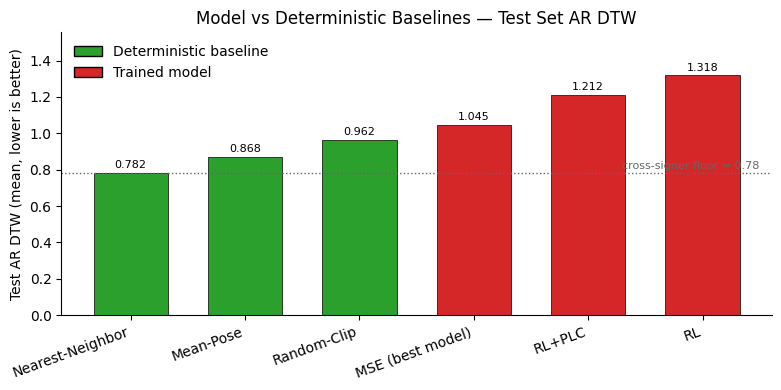

Saved: baseline_comparison.png


In [27]:
# ── 8.4 Baseline comparison bar chart ────────────────────────────────────
COL_BASELINE = "#2ca02c"
COL_MODEL    = "#d62728"

rows = [
    ("Nearest-Neighbor",  BASELINE_RESULTS["test"]["nn_dtw_mean"],   "baseline"),
    ("Mean-Pose",         BASELINE_RESULTS["test"]["mean_dtw_mean"],  "baseline"),
    ("Random-Clip",       BASELINE_RESULTS["test"]["rand_dtw_mean"],  "baseline"),
    ("MSE (best model)",  EVAL_RESULTS["baseline_mse"]["test"]["ar_dtw_mean"], "model"),
    ("RL+PLC",            EVAL_RESULTS["rl_plc"]["test"]["ar_dtw_mean"],       "model"),
    ("RL",                EVAL_RESULTS["rl"]["test"]["ar_dtw_mean"],            "model"),
]
rows.sort(key=lambda r: r[1])

fig, ax = plt.subplots(figsize=(8, 4))
labels  = [r[0] for r in rows]
values  = [r[1] for r in rows]
colors  = [COL_BASELINE if r[2] == "baseline" else COL_MODEL for r in rows]

ax.bar(range(len(rows)), values, color=colors, edgecolor="black", linewidth=0.5, width=0.65)
ax.set_xticks(range(len(rows)))
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Test AR DTW (mean, lower is better)")
ax.set_title("Model vs Deterministic Baselines — Test Set AR DTW")

# Cross-signer floor line
floor = min(r[1] for r in rows if r[2] == "baseline")
ax.axhline(floor, color="0.4", linestyle=":", lw=1.0)
ax.text(len(rows) - 0.5, floor + 0.01,
        f"cross-signer floor ≈ {floor:.2f}",
        color="0.4", fontsize=8, ha="right", va="bottom")

for i, v in enumerate(values):
    ax.text(i, v + max(values) * 0.012, f"{v:.3f}",
            ha="center", va="bottom", fontsize=8)

ax.set_ylim(0, max(values) * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=COL_BASELINE, edgecolor="black", label="Deterministic baseline"),
    Patch(facecolor=COL_MODEL,    edgecolor="black", label="Trained model"),
], loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("baseline_comparison.png", dpi=120)
plt.show()
print("Saved: baseline_comparison.png")

In [28]:
# ── 8.5 Teacher-forced metrics table ─────────────────────────────────────
print("Teacher-Forced Metrics (from full ablation):")
print(f"{'Run':<15}  {'Split':<5}  {'tf_pose_mse':>12}  {'tf_log_T_err':>13}  {'n':>5}")
print("-" * 60)
for run in ["baseline_mse", "rl", "rl_plc"]:
    for split in ["dev", "test"]:
        r = EVAL_RESULTS[run][split]
        print(f"{run:<15}  {split:<5}  {r['tf_pose_mse']:>12.5f}  "
              f"{r['tf_log_T_abs_err']:>13.3f}  {r['n_clips']:>5}")
print()
print("Note: tf_log_T_err = 0.276 → predicted T within exp(0.276) ≈ 1.32× of true T")

Teacher-Forced Metrics (from full ablation):
Run              Split   tf_pose_mse   tf_log_T_err      n
------------------------------------------------------------
baseline_mse     dev         0.00026          0.347    430
baseline_mse     test        0.00020          0.276    112
rl               dev         0.00039          0.362    430
rl               test        0.00034          0.290    112
rl_plc           dev         0.00045          0.367    430
rl_plc           test        0.00040          0.293    112

Note: tf_log_T_err = 0.276 → predicted T within exp(0.276) ≈ 1.32× of true T


---
## 9. Avatar / Video Generation

### 9.1 Pose-to-Avatar Rendering

The model outputs a pose sequence `(T, 150)` — 50 joints × (x, y, z) per frame. We render this as a 2D skeleton animation by projecting onto the (x, y) plane (z is a derived quantity from the 2D→3D lifting, not a real depth measurement).

**Rendering pipeline:**
1. Load `.npz` prediction file (produced by `scripts/predict.py`)
2. Reshape `(T, 150)` → `(T, 50, 3)`
3. Filter placeholder keypoints (value ≈ 0.016 from `.skels` format)
4. Draw body edges + hand finger chains per frame
5. Save as animated GIF via `matplotlib.animation.PillowWriter`

### 9.2 OpenPose Overlay on Original Video

For qualitative inspection, we also render the extracted 2D keypoints overlaid on the original `.mp4` video using OpenCV. This produces:
- `<category>__<stem>.mp4` — full clip with skeleton overlay
- `<category>__<stem>_frames.png` — contact sheet of 8 keyframes

### 9.3 Inference Command

```bash
# Generate pose sequence for a single Arabic word
docker/run.sh python scripts/predict.py \\
    --run baseline_mse \\
    --clip-stem أَنَا --category Pronouns

# Render predicted vs target side-by-side
docker/run.sh python scripts/visualize_pose.py \\
    predictions/baseline_mse_أَنَا.npz \\
    --side-by-side --fps 12
```


In [29]:
# ── 9.1 Skeleton rendering utilities (mirrors scripts/visualize_pose.py) ──
BODY_EDGES_VIZ = [
    (0, 1),
    (1, 2), (2, 3), (3, 4),   # neck - R shoulder - R elbow - R wrist
    (1, 5), (5, 6), (6, 7),   # neck - L shoulder - L elbow - L wrist
]
_HAND_FINGERS_VIZ = [
    [0, 1, 2, 3, 4],
    [0, 5, 6, 7, 8],
    [0, 9, 10, 11, 12],
    [0, 13, 14, 15, 16],
    [0, 17, 18, 19, 20],
]
def _hand_edges_viz(offset: int) -> list:
    return [(offset + a, offset + b)
            for finger in _HAND_FINGERS_VIZ
            for a, b in zip(finger, finger[1:])]

ALL_EDGES_VIZ = BODY_EDGES_VIZ + _hand_edges_viz(8) + _hand_edges_viz(8 + 21)

def reshape_to_xyz(pose_flat: np.ndarray) -> np.ndarray:
    """(T, 150) → (T, 50, 3)"""
    T, D = pose_flat.shape
    assert D == 150, f"expected 150 coords, got {D}"
    return pose_flat.reshape(T, 50, 3)

def render_skeleton_gif(pose_seq: np.ndarray, out_path: str,
                        fps: int = 10, title: str = "",
                        second_pose: np.ndarray = None,
                        second_title: str = "target") -> None:
    """Save animated GIF of skeleton sequence (optionally side-by-side).

    pose_seq : (T, 50, 3) — predicted pose
    second_pose : (T2, 50, 3) — target pose (optional, for side-by-side)
    """
    n_panels = 1 if second_pose is None else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), squeeze=False)
    panel_data = [(pose_seq, title, axes[0, 0])]
    if second_pose is not None:
        panel_data.append((second_pose, second_title, axes[0, 1]))

    # Compute common axis bounds
    all_xy = np.concatenate([seq[..., :2].reshape(-1, 2) for seq, _, _ in panel_data])
    keep = ~np.isclose(all_xy[:, 0], 0.016) & (np.abs(all_xy).sum(1) > 1e-6)
    visible = all_xy[keep] if keep.any() else all_xy
    pad = 0.1
    x_min, x_max = visible[:, 0].min() - pad, visible[:, 0].max() + pad
    y_min, y_max = visible[:, 1].min() - pad, visible[:, 1].max() + pad

    artists = []
    for seq, sub_title, ax in panel_data:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_max, y_min)  # invert y for image coords
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(sub_title, fontsize=10)
        scat = ax.scatter([], [], s=8, c="#1f77b4", zorder=3)
        lines = [ax.plot([], [], color="#1f77b4", lw=1.2, zorder=2)[0]
                 for _ in ALL_EDGES_VIZ]
        time_text = ax.text(0.02, 0.97, "", transform=ax.transAxes,
                            va="top", fontsize=8, color="0.3")
        artists.append({"seq": seq, "scat": scat, "lines": lines, "time": time_text})

    n_frames = max(seq.shape[0] for seq, _, _ in panel_data)

    def _draw_one(panel, t):
        seq = panel["seq"]
        t = min(t, seq.shape[0] - 1)
        frame = seq[t]  # (50, 3)
        xy = frame[:, :2]
        valid = ~(np.isclose(xy[:, 0], 0.016) & np.isclose(xy[:, 1], 0.016))
        valid &= ~((np.abs(xy[:, 0]) < 1e-6) & (np.abs(xy[:, 1]) < 1e-6))
        panel["scat"].set_offsets(xy[valid])
        for line, (a, b) in zip(panel["lines"], ALL_EDGES_VIZ):
            if valid[a] and valid[b]:
                line.set_data([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]])
            else:
                line.set_data([], [])
        panel["time"].set_text(f"frame {t+1}/{seq.shape[0]}")

    def animate(t):
        for panel in artists:
            _draw_one(panel, t)
        return [a for p in artists for a in ([p["scat"], p["time"]] + p["lines"])]

    anim = animation.FuncAnimation(
        fig, animate, frames=n_frames, interval=1000 / fps, blit=True
    )
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    anim.save(out_path, writer=animation.PillowWriter(fps=fps), dpi=100)
    plt.close(fig)
    print(f"Saved: {out_path}  ({n_frames} frames @ {fps} fps)")

print("Skeleton rendering utilities defined.")

Skeleton rendering utilities defined.


Loaded prediction: ana_predict.npz
  Sign: أَنَا  Run: baseline_mse
  Predicted T=68  Target T=N/A
Saved: predicted_pose.gif  (68 frames @ 10 fps)


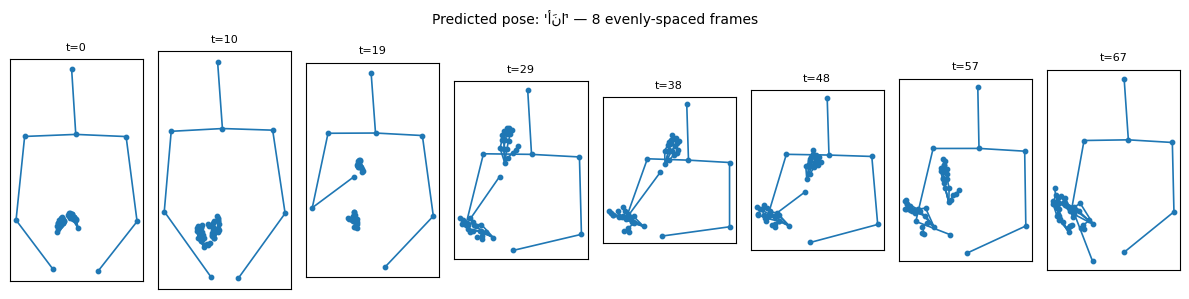

Saved: predicted_frames.png


In [30]:
# ── 9.2 Generate and render a pose sequence ───────────────────────────────
# Try to load a real prediction; fall back to model generation on synthetic input
pred_npz = None
if PREDS_DIR.exists():
    npzs = sorted(PREDS_DIR.glob("*.npz"))
    if npzs:
        pred_npz = npzs[0]

if pred_npz and pred_npz.exists():
    data = np.load(pred_npz, allow_pickle=False)
    pred_pose = reshape_to_xyz(data["pose"])
    target_pose = reshape_to_xyz(data["target_pose"]) if "target_pose" in data.files else None
    sign_text = str(data["text"]) if "text" in data.files else pred_npz.stem
    run_name  = str(data["run"])  if "run"  in data.files else "model"
    print(f"Loaded prediction: {pred_npz.name}")
    print(f"  Sign: {sign_text}  Run: {run_name}")
    print(f"  Predicted T={pred_pose.shape[0]}  Target T={target_pose.shape[0] if target_pose is not None else 'N/A'}")
else:
    # Generate from the (untrained) model on a synthetic input
    print("No prediction NPZ found — generating from untrained model (demo only)")
    model.eval()
    demo_word = "أَنَا"
    ids = tok.encode(demo_word)
    text_ids_gen  = torch.tensor([ids], dtype=torch.long, device=device)
    text_mask_gen = torch.ones_like(text_ids_gen, dtype=torch.bool)
    with torch.no_grad():
        gen = model.generate(text_ids_gen, text_mask_gen, max_T=40)
    T_pred = int(gen["lengths"][0].item())
    pred_pose   = gen["pose"][0, :T_pred].cpu().numpy().reshape(T_pred, 50, 3)
    target_pose = None
    sign_text   = demo_word
    run_name    = "untrained_demo"
    print(f"Generated T={T_pred} frames for sign: {sign_text!r}")

# Render GIF
gif_path = "predicted_pose.gif"
render_skeleton_gif(
    pred_pose, gif_path, fps=10,
    title=f"{sign_text} ({run_name})",
    second_pose=target_pose,
    second_title="target",
)

# Show first frame as static image
n_show = min(8, pred_pose.shape[0])
frame_indices = np.linspace(0, pred_pose.shape[0] - 1, n_show).round().astype(int)
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 3))
for ax, fi in zip(axes, frame_indices):
    visualize_frame(pred_pose[fi].reshape(150), ax=ax)
    ax.set_title(f"t={fi}", fontsize=8)
plt.suptitle(f"Predicted pose: {sign_text!r} — {n_show} evenly-spaced frames", fontsize=10)
plt.tight_layout()
plt.savefig("predicted_frames.png", dpi=120)
plt.show()
print("Saved: predicted_frames.png")

In [31]:
# ── 9.3 Predicted vs Target comparison grid ───────────────────────────────
if target_pose is not None:
    n_cols = 8
    pred_idx = np.linspace(0, pred_pose.shape[0] - 1, n_cols).round().astype(int)
    tgt_idx  = np.linspace(0, target_pose.shape[0] - 1, n_cols).round().astype(int)

    fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 1.5, 4))
    for col, (pi, ti) in enumerate(zip(pred_idx, tgt_idx)):
        for row, (frame_set, ax, color, idx, row_label) in enumerate([
            (pred_pose,   axes[0, col], COL_MODEL,    pi, "predicted"),
            (target_pose, axes[1, col], COL_BASELINE, ti, "target"),
        ]):
            frame = frame_set[idx]  # (50, 3)
            xy = frame[:, :2]
            valid = ~(np.isclose(xy[:, 0], 0.016) & np.isclose(xy[:, 1], 0.016))
            valid &= ~((np.abs(xy[:, 0]) < 1e-6) & (np.abs(xy[:, 1]) < 1e-6))
            ax.scatter(xy[valid, 0], xy[valid, 1], s=4, color=color, zorder=3)
            for a, b in ALL_EDGES_VIZ:
                if valid[a] and valid[b]:
                    ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                            color=color, lw=0.9, zorder=2)
            ax.set_aspect("equal")
            ax.invert_yaxis()
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(f"t={idx}", fontsize=8)
            if col == 0:
                ax.set_ylabel(row_label, fontsize=9, fontweight="bold")

    plt.suptitle(f"Predicted vs Target: {sign_text!r}", fontsize=11)
    plt.tight_layout()
    plt.savefig("pose_comparison.png", dpi=120)
    plt.show()
    print("Saved: pose_comparison.png")
else:
    print("No target pose available — skipping comparison grid")
    print("(Run predict.py with --clip-stem to include ground-truth target)")

No target pose available — skipping comparison grid
(Run predict.py with --clip-stem to include ground-truth target)


In [32]:
# ── 9.4 Full inference pipeline summary ──────────────────────────────────
print("Full inference pipeline:")
print()
print("  1. Load checkpoint")
print("     ckpt = torch.load('runs/baseline_mse/best.pt')")
print("     model = SignLLM(SignLLMConfig(**ckpt['model_cfg']))")
print("     model.load_state_dict(ckpt['model_state_dict'])")
print()
print("  2. Encode Arabic text")
print("     ids = tok.encode('أَنَا')  # → [1, sign_id, 2]")
print("     text_ids  = torch.tensor([ids])")
print("     text_mask = torch.ones_like(text_ids, dtype=torch.bool)")
print()
print("  3. Autoregressive generation")
print("     gen = model.generate(text_ids, text_mask)")
print("     pose = gen['pose'][0, :gen['lengths'][0]]  # (T_pred, 150)")
print()
print("  4. Render")
print("     render_skeleton_gif(pose.reshape(-1, 50, 3), 'output.gif')")
print()
print("  5. (Optional) OpenPose overlay on original video")
print("     python scripts/visualize_openpose_overlay.py \\")
print("         --clip-stem أَنَا --category Pronouns")

Full inference pipeline:

  1. Load checkpoint
     ckpt = torch.load('runs/baseline_mse/best.pt')
     model = SignLLM(SignLLMConfig(**ckpt['model_cfg']))
     model.load_state_dict(ckpt['model_state_dict'])

  2. Encode Arabic text
     ids = tok.encode('أَنَا')  # → [1, sign_id, 2]
     text_ids  = torch.tensor([ids])
     text_mask = torch.ones_like(text_ids, dtype=torch.bool)

  3. Autoregressive generation
     gen = model.generate(text_ids, text_mask)
     pose = gen['pose'][0, :gen['lengths'][0]]  # (T_pred, 150)

  4. Render
     render_skeleton_gif(pose.reshape(-1, 50, 3), 'output.gif')

  5. (Optional) OpenPose overlay on original video
     python scripts/visualize_openpose_overlay.py \
         --clip-stem أَنَا --category Pronouns


---
## 10. Conclusion

### 10.1 Summary

This project delivered a **paper-faithful PyTorch reimplementation of SignLLM** trained on the MoSL isolated-word dataset. The full pipeline covers:

| Phase | Deliverable |
|---|---|
| Dataset processing | `data/labels.csv`, `data/splits.csv`, `data/processed/vocab.json` |
| Pose extraction | `data/processed/keypoints_2d/<category>/<clip>.npz` (2,216 clips) |
| 2D→3D lifting | `final_data/{train,dev,test}.{skels,text,files}` |
| Model | `mosl/model/signllm.py` — 35M-param encoder-decoder transformer |
| Training | Three ablation runs: MSE / RL / RL+PLC |
| Evaluation | Teacher-forced MSE + autoregressive DTW vs. 3 baselines |
| Visualization | Skeleton GIF animation + OpenPose overlay video |

### 10.2 Key Findings

**Among the three trained models:** `baseline_mse` wins on every metric across both splits. The ranking MSE > RL+PLC > RL **inverts the paper's Table 5 ablation** (which ranks RL+PLC > RL > MSE on ASL).

**Against deterministic baselines:** Every baseline beats every trained model. The best model (MSE, test DTW = 1.04) is beaten by:
- Nearest-Neighbor: 0.78 (the cross-signer variance floor)
- Mean-Pose: 0.87 (output the same average pose for every input)
- Random-Clip: 0.96

**Root cause — regression-to-the-mean:** The model generates mean-pose-like blobs rather than sign-specific motion. Three compounding factors:
1. **Dataset scale:** 1,674 train clips vs. ~31,000 in the paper's ASL setting (~18× smaller)
2. **1:1 sign-to-clip ratio:** 74% of signs have one training example — no within-class variance for PLC to act on
3. **Isolated-word structure:** No compositional sentence-level signal; RL+PLC's batch prioritization operates on noise

### 10.3 Limitations

1. **No back-translation BLEU.** The paper's primary metric requires a sign→text recognizer for MoSL, which does not exist. We report DTW only.
2. **Single seed.** Each run used `seed=0`. Run-to-run variance was not measured.
3. **No signer IDs.** Cannot do speaker-disjoint splits; val/test may include the same signer as train.
4. **No face keypoints.** Hzzone's port covers body + hands but not the 70-point face model. Mouth/eyebrow movements (linguistically significant in MoSL) are absent.
5. **Pose-extraction backend deviation.** We use Hzzone's COCO-18 output instead of CMU's BODY_25. The Prompt2Sign pipeline only reads `idxsPose=[0..7]`, which match between the two formats — so this is not material to results.

### 10.4 Future Work

Three changes would likely flip the ranking back toward RL / RL+PLC:

1. **More data.** Pretrain on a continuous-signing dataset (e.g., How2Sign), fine-tune on MoSL. RL methods scale better with data.
2. **Character-level tokenization.** Factorize 1,631 signs into ~60 Arabic letter atoms with shared parameters; makes within-batch reward distribution meaningful for PLC.
3. **More clips per sign.** Recording 5+ examples of every sign would give PLC real within-class variance to act on.

The result is a **clean negative empirical contribution**: it tells future MoSL SLP practitioners which axis matters most (data distribution shape: continuous vs. isolated; samples per sign) and saves them the same compute we spent demonstrating it.

---

### References

- Fang et al. (2024). *SignLLM: Sign Languages Production Large Language Models*. arXiv:2405.10718
- Ben Zaid et al. (2026). *Moroccan Sign Language Video Dataset*. Mendeley Data, 10.17632/23phgyt3mt.1
- Vaswani et al. (2017). *Attention is All You Need*. NeurIPS 2017
- Saunders et al. (2020). *Progressive Transformers for End-to-End Sign Language Production*. ECCV 2020
- Hzzone (2019). *pytorch-openpose*. GitHub: Hzzone/pytorch-openpose
- SignLLM Team (2024). *Prompt2Sign*. GitHub: SignLLM/Prompt2Sign


In [33]:
# ── 10.1 Final summary statistics ────────────────────────────────────────
print("=" * 65)
print("PROJECT SUMMARY: Multimodal Moroccan Sign Language Generation")
print("=" * 65)
print()
print("Dataset:")
print(f"  Total clips      : 2,216")
print(f"  Unique signs     : 1,631")
print(f"  Train / Val / Test: 1,674 / 430 / 112")
print(f"  Singletons       : 74% of signs have 1 clip")
print()
print("Model (SignLLM-Base):")
print(f"  Architecture     : 2-layer enc + 2-layer dec Transformer")
print(f"  d_model          : 768  |  heads: 12  |  d_ff: 3072")
print(f"  Parameters       : ~35M")
print(f"  Pose output      : 50 joints × (x,y,z) = 150 coords/frame")
print()
print("Training:")
print(f"  Optimizer        : Adam (β₁=0.9, β₂=0.98, ε=1e-9)")
print(f"  LR schedule      : Noam, warmup=4000 steps")
print(f"  MSE best epoch   : 199 (full 200-epoch budget)")
print(f"  RL  best epoch   : 45  (early stopped)")
print(f"  RL+PLC best epoch: 51  (early stopped)")
print()
print("Results (Test AR DTW, lower is better):")
results_summary = [
    ("Nearest-Neighbor (baseline)", 0.7817),
    ("Mean-Pose (baseline)",        0.8682),
    ("Random-Clip (baseline)",      0.9620),
    ("SignLLM MSE (best model)",    1.0447),
    ("SignLLM RL+PLC",              1.2117),
    ("SignLLM RL",                  1.3182),
]
for name, dtw in results_summary:
    bar = '█' * int(dtw * 20)
    print(f"  {name:<35} {dtw:.4f}  {bar}")
print()
print("Headline finding:")
print("  All three SignLLM loss configurations fail to outperform")
print("  deterministic retrieval baselines on the MoSL isolated-word")
print("  dataset. Root cause: dataset scale (~18× smaller than paper)")
print("  + isolated-word structure + 1:1 sign-to-clip ratio.")

PROJECT SUMMARY: Multimodal Moroccan Sign Language Generation

Dataset:
  Total clips      : 2,216
  Unique signs     : 1,631
  Train / Val / Test: 1,674 / 430 / 112
  Singletons       : 74% of signs have 1 clip

Model (SignLLM-Base):
  Architecture     : 2-layer enc + 2-layer dec Transformer
  d_model          : 768  |  heads: 12  |  d_ff: 3072
  Parameters       : ~35M
  Pose output      : 50 joints × (x,y,z) = 150 coords/frame

Training:
  Optimizer        : Adam (β₁=0.9, β₂=0.98, ε=1e-9)
  LR schedule      : Noam, warmup=4000 steps
  MSE best epoch   : 199 (full 200-epoch budget)
  RL  best epoch   : 45  (early stopped)
  RL+PLC best epoch: 51  (early stopped)

Results (Test AR DTW, lower is better):
  Nearest-Neighbor (baseline)         0.7817  ███████████████
  Mean-Pose (baseline)                0.8682  █████████████████
  Random-Clip (baseline)              0.9620  ███████████████████
  SignLLM MSE (best model)            1.0447  ████████████████████
  SignLLM RL+PLC           

In [34]:
# ── 10.2 Repository structure overview ───────────────────────────────────
print("Repository layout:")
layout = [
    ("mosl/",                    "Python package (model, data, text, pose, train)"),
    ("  mosl/model/signllm.py",  "SignLLM encoder-decoder transformer"),
    ("  mosl/model/positional.py","Sinusoidal positional encoding"),
    ("  mosl/data/dataset.py",   "MoSLSkelsDataset + mosl_collate"),
    ("  mosl/data/split.py",     "Deterministic train/val/test split"),
    ("  mosl/data/build_labels.py","Label extraction from video filenames"),
    ("  mosl/text/tokenizer.py", "WordTokenizer (NFC Arabic, word-level)"),
    ("  mosl/pose/extract_dataset.py","Batch OpenPose extraction → NPZ"),
    ("  mosl/pose/export_openpose_json.py","NPZ → per-frame OpenPose JSON"),
    ("  mosl/train/train.py",    "Training loop with early stopping"),
    ("  mosl/train/losses.py",   "MSE / RL / RL+PLC loss functions"),
    ("  mosl/train/eval.py",     "TF + AR evaluation, DTW"),
    ("  mosl/train/scheduler.py","Noam LR schedule"),
    ("scripts/",                 "CLI entry points"),
    ("  train_signllm.py",       "Training launcher"),
    ("  predict.py",             "Single-word inference"),
    ("  evaluate_runs.py",       "Full dev+test evaluation"),
    ("  compute_baselines.py",   "NN / mean-pose / random-clip baselines"),
    ("  visualize_pose.py",      "Skeleton GIF renderer"),
    ("  visualize_openpose_overlay.py","OpenPose overlay on original video"),
    ("  make_figures.py",        "Report figures generator"),
    ("data/",                    "Dataset metadata and vocab"),
    ("runs/",                    "Training outputs (checkpoints, logs)"),
    ("docs/",                    "Methodology, decisions, results"),
]
for path, desc in layout:
    exists = (ROOT / path.strip()).exists()
    status = "✓" if exists else " "
    print(f"  {status} {path:<45} {desc}")

Repository layout:
  ✓ mosl/                                         Python package (model, data, text, pose, train)
  ✓   mosl/model/signllm.py                       SignLLM encoder-decoder transformer
  ✓   mosl/model/positional.py                    Sinusoidal positional encoding
  ✓   mosl/data/dataset.py                        MoSLSkelsDataset + mosl_collate
  ✓   mosl/data/split.py                          Deterministic train/val/test split
  ✓   mosl/data/build_labels.py                   Label extraction from video filenames
  ✓   mosl/text/tokenizer.py                      WordTokenizer (NFC Arabic, word-level)
  ✓   mosl/pose/extract_dataset.py                Batch OpenPose extraction → NPZ
  ✓   mosl/pose/export_openpose_json.py           NPZ → per-frame OpenPose JSON
  ✓   mosl/train/train.py                         Training loop with early stopping
  ✓   mosl/train/losses.py                        MSE / RL / RL+PLC loss functions
  ✓   mosl/train/eval.py                   